In [498]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

# Pre-processing

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


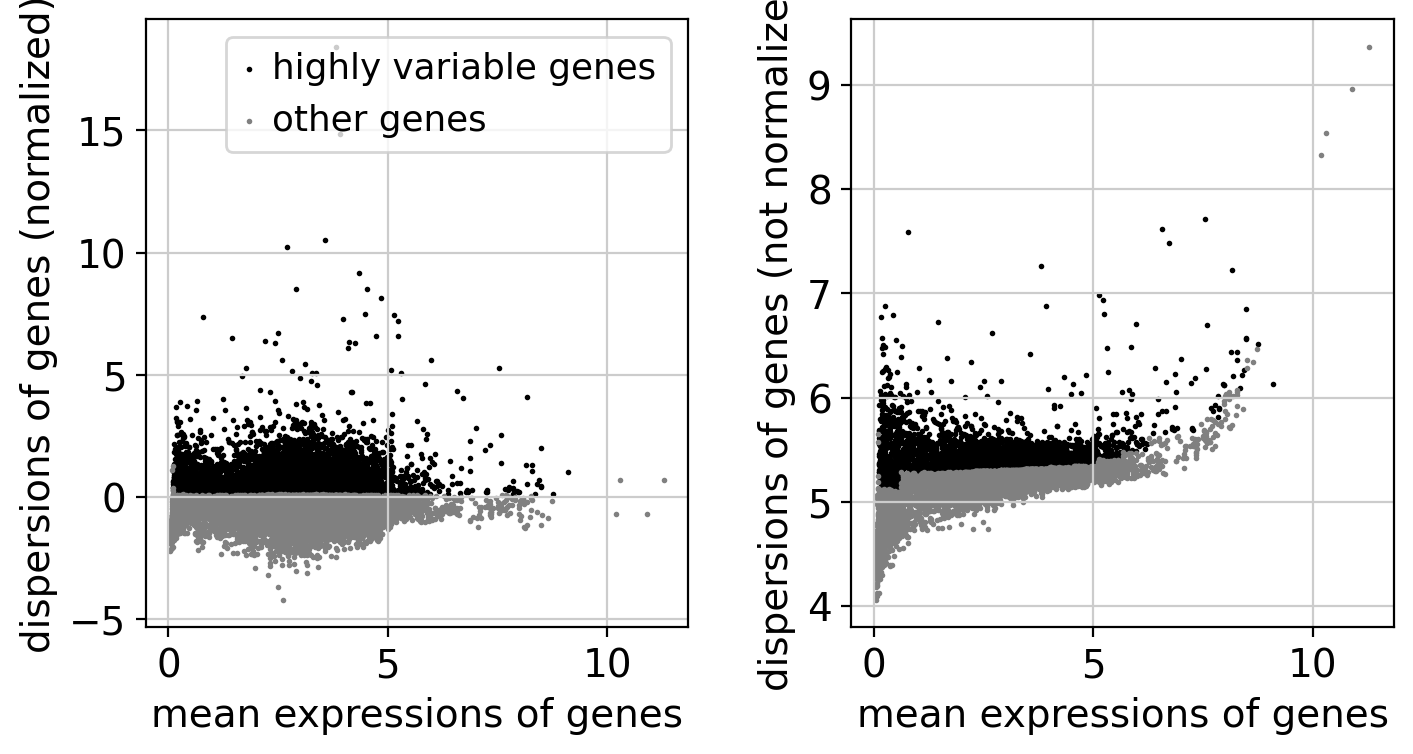

there are 5502 hvgs


In [499]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
sc.pp.filter_genes(avis, min_cells=10)
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.1, max_mean=10, min_disp=0.1)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

In [500]:
# > lymph node
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
sc.pp.filter_genes(avis, min_cells=10)
avis2 = avis.copy()
# add necessary attributes from metadata
avis2.obs['sample_id'] = 'sample'
avis2.obsm['spatial'] = avis2.obs[['imagerow','imagecol']].values

In [501]:
# retrieve the ENSG to GENE SYMBOL conversion
symbol2id = avis2.var.loc[avis2.var.index.intersection(genes), 'gene_id'].to_dict()
id2symbol = {v:k for k,v in symbol2id.items()}

In [502]:
# read in the PPI via HURI
pairs = pd.read_table('data/HI-union.tsv', header=None)
# convert to symbol and remove the irrelevant
pairs[0] = pairs[0].map(id2symbol)
pairs[1] = pairs[1].map(id2symbol)
pairs = pairs.dropna()
# check how many genes are relevant
genes = list(set(pairs.values.flatten()))
print(len(genes))
pairs = [sorted(x) for x in pairs.values.tolist()]

1770


In [503]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()
avis1 = avis1[avis1.X.sum(1).A1 > 0].copy()
avis2 = avis2[avis2.X.sum(1) > 0].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('../celcomen/data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('../celcomen/data/preproc_lymphnode.h5ad')

# Run inference module to learn intra- and inter-cellular gene-gene forces

In [504]:
# load model
from celcomen.models.celcomen import celcomen

from celcomen.training_plan.train import train
from celcomen.datareaders.datareader import get_dataset_loaders

from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [515]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_lymphnode.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 1770], edge_index=[2, 18618], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 1770], edge_index=[2, 14592], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 1770], edge_index=[2, 18600], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 1770], edge_index=[2, 12912], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4034, 1770], edge_index=[2, 24204], y=[1], pos=[4034, 2], batch=[4034], ptr=[2])



### Select the hyperparameters of the model.
zmft_scalar should be the highest value in the range (0,1) such that the loss can be stably minimized. 
n_neighbors should be selected based on what disentanglement we want to achieve in the data. n_neighbors=6 targets disentanglement between intracellular and intercellular forces of short range.

In [516]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-2
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:05<00:00,  1.50s/it]


In [194]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-4
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model2.to('cpu')
# train the models
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:01<00:00,  2.07it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

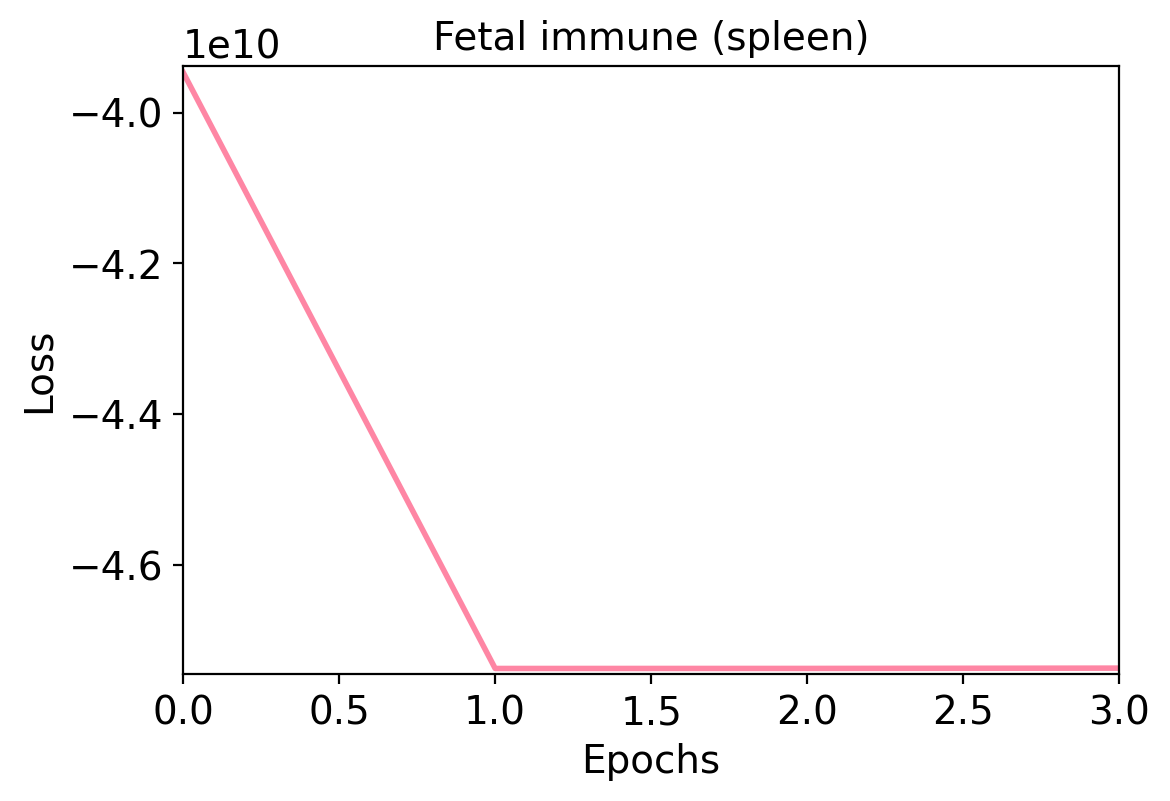

In [200]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

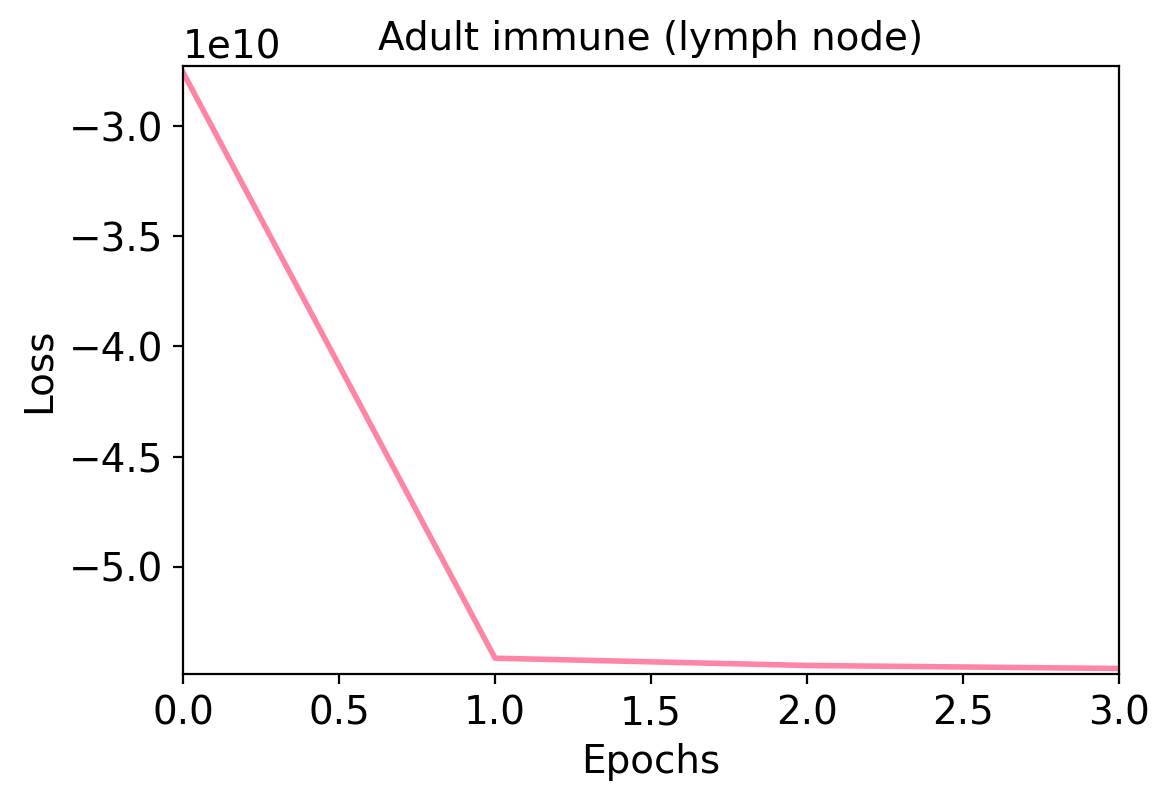

In [199]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

### systematic evaluation

In [201]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)

In [ ]:
# create whitelist
pairs_str = [':'.join(x) for x in pairs]
pairs_str += [':'.join(x[::-1]) for x in pairs]

In [224]:
def retrieve_posneg(df):
    # assemble the data
    tmps = []
    for idx, x in enumerate(df.index):
        tmp = df_inter.loc[x][idx:]
        tmp.index = x + ':' + tmp.index
        tmps.append(tmp)
    tmp = pd.concat(tmps, axis=0)
    print('assembled')
    ys_pred = tmp
    ys_true = 1 * tmp.index.isin(pairs_str)
    return ys_pred, ys_true

In [225]:
from sklearn.metrics import roc_curve, auc, f1_score, precision_recall_curve

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

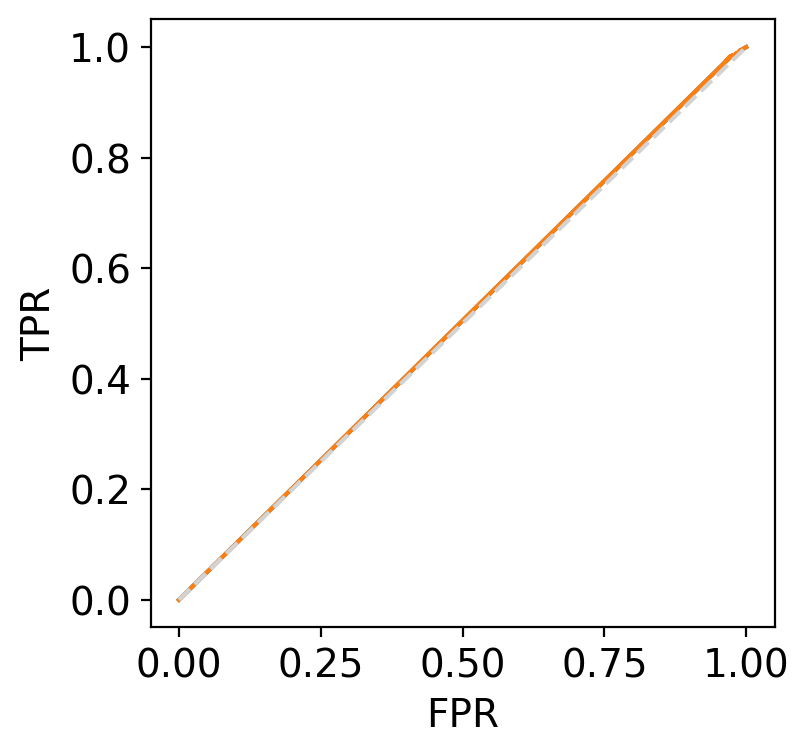

In [225]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

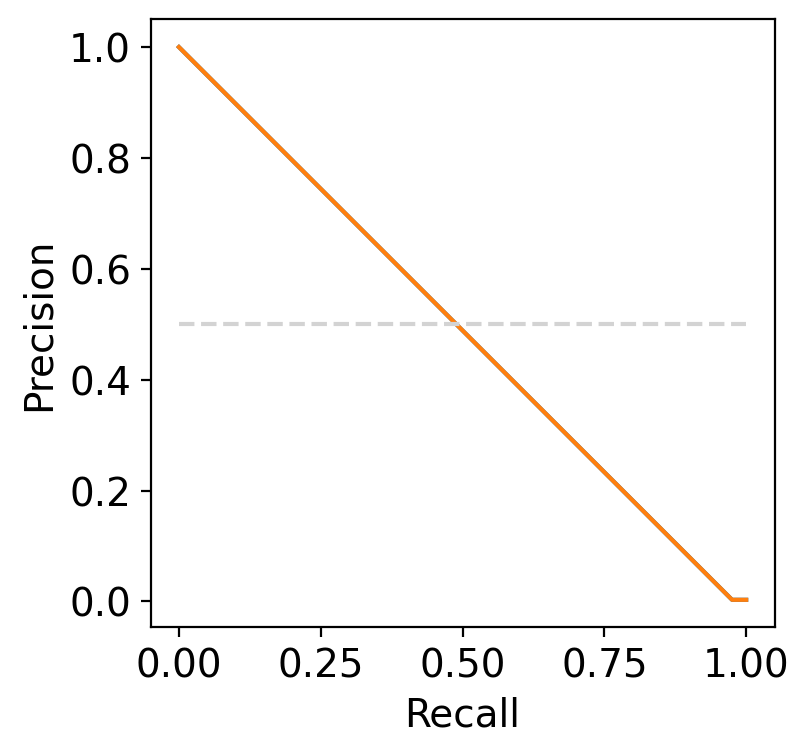

In [229]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [230]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

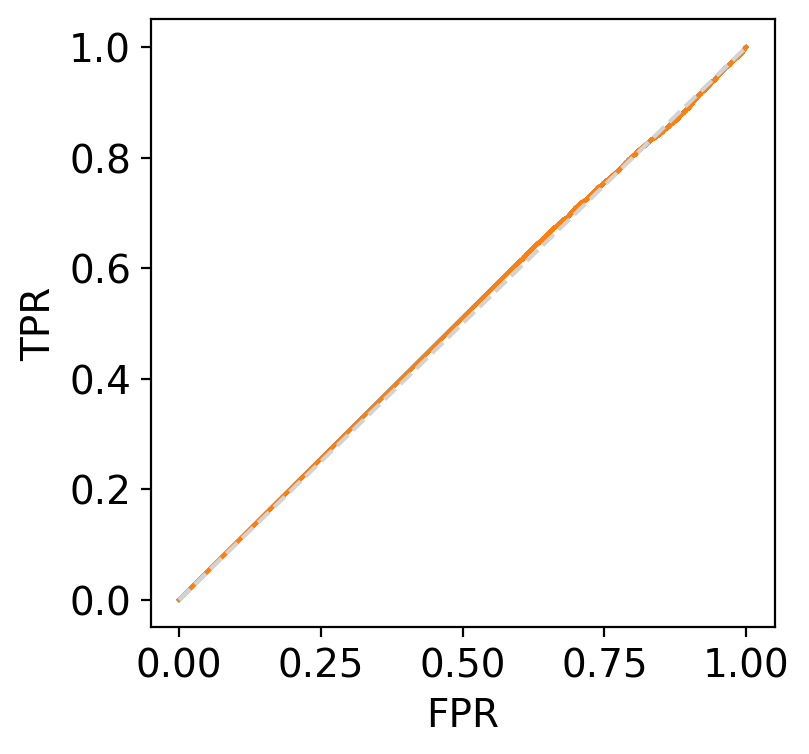

In [234]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

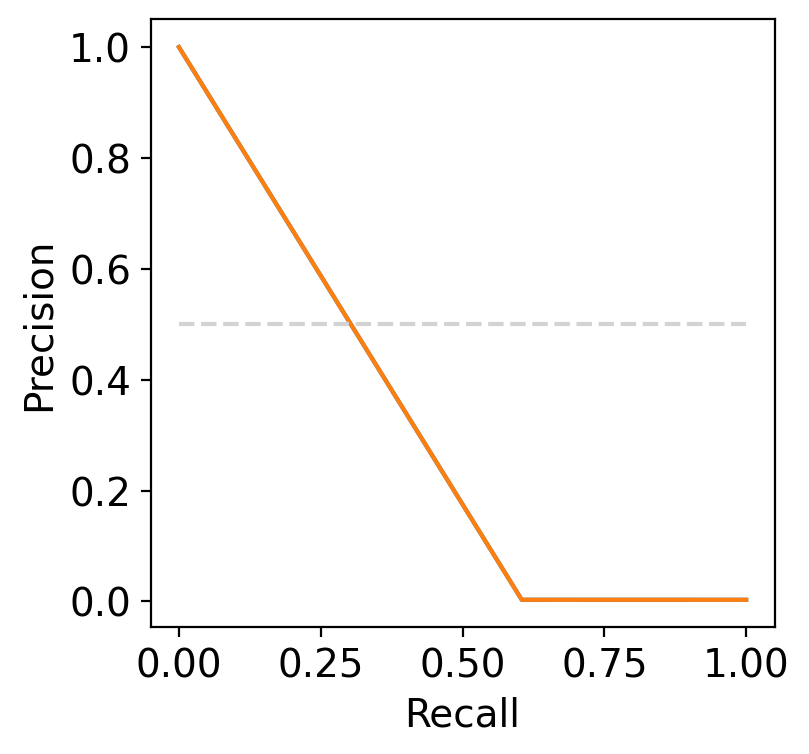

In [235]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

## increase training

In [246]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-5
zmft_scalar = 1e-1
seed = 0
epochs = 20

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 20/20 [00:22<00:00,  1.10s/it]


In [250]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-5
zmft_scalar = 1e-1
seed = 0
epochs = 20

# instantiate models on cpu
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model2.to('cpu')
# train the models
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 20/20 [00:09<00:00,  2.20it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

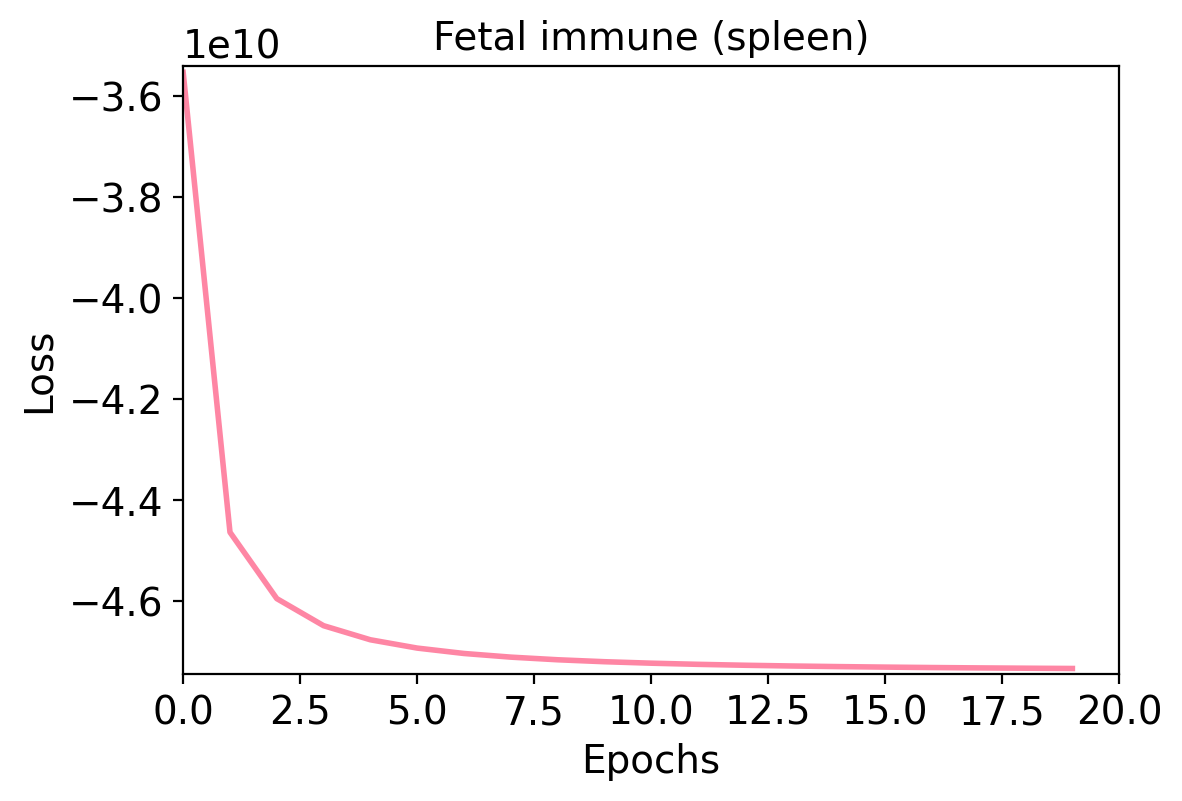

In [248]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, 20)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

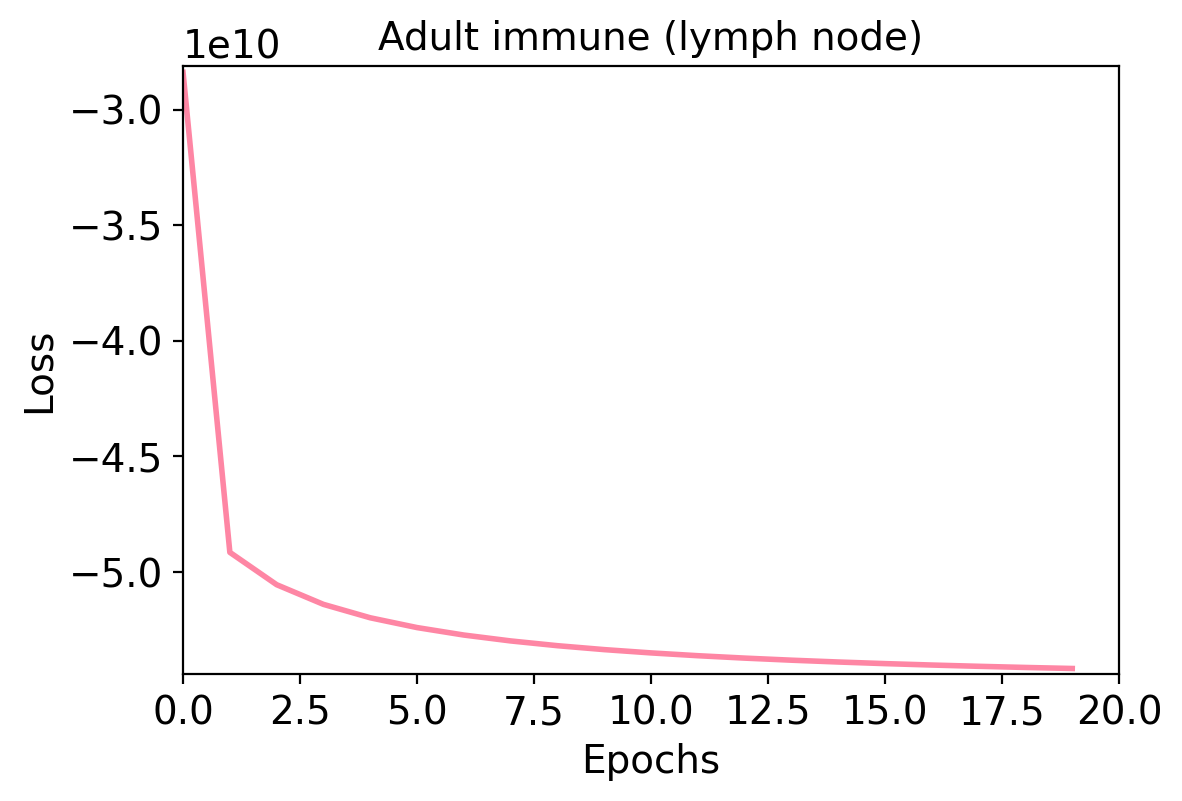

In [251]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, 20)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

In [253]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

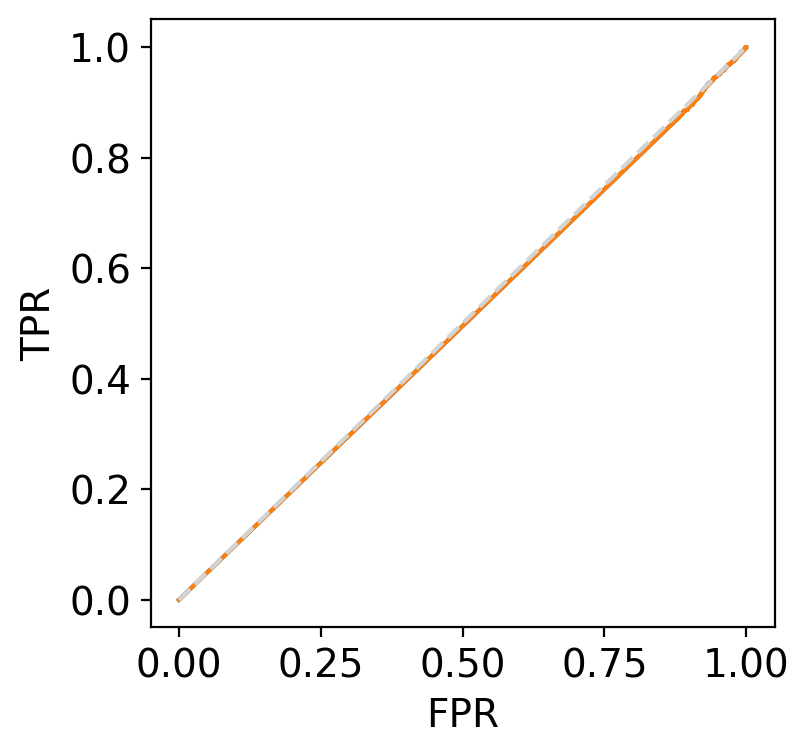

In [254]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

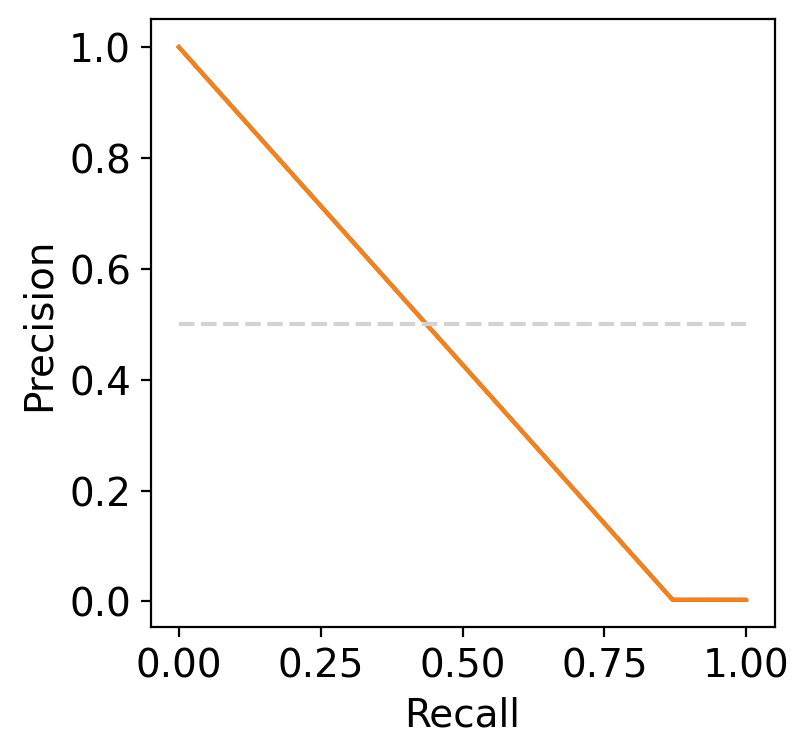

In [255]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [256]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

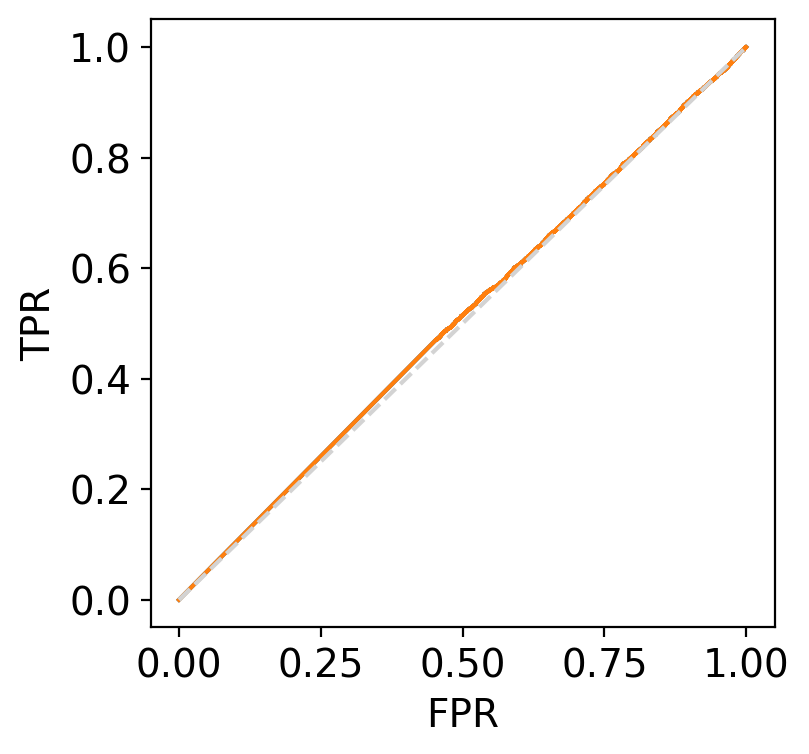

In [257]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

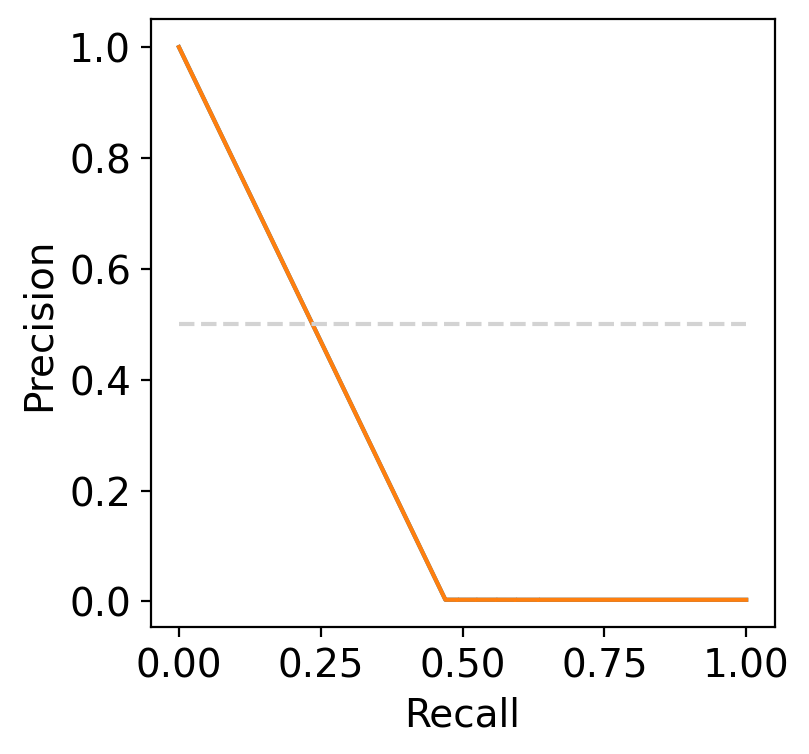

In [258]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [259]:
def retrieve_posneg(df):
    # assemble the data
    tmps = []
    for idx, x in enumerate(df.index):
        tmp = df_inter.loc[x][idx+1:]
        tmp.index = x + ':' + tmp.index
        tmps.append(tmp)
    tmp = pd.concat(tmps, axis=0)
    print('assembled')
    ys_pred = tmp
    ys_true = 1 * tmp.index.isin(pairs_str)
    return ys_pred, ys_true

In [260]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

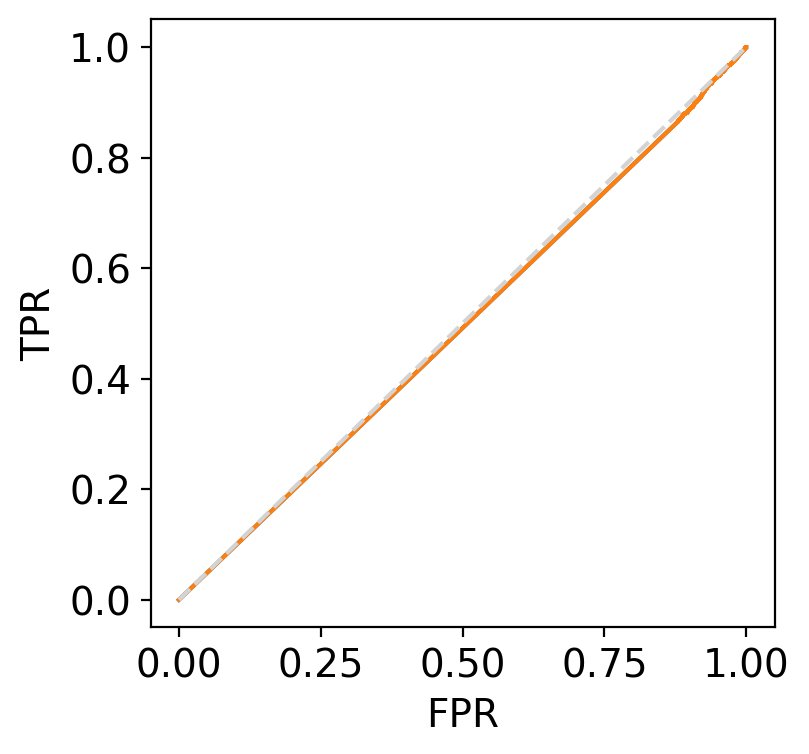

In [261]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

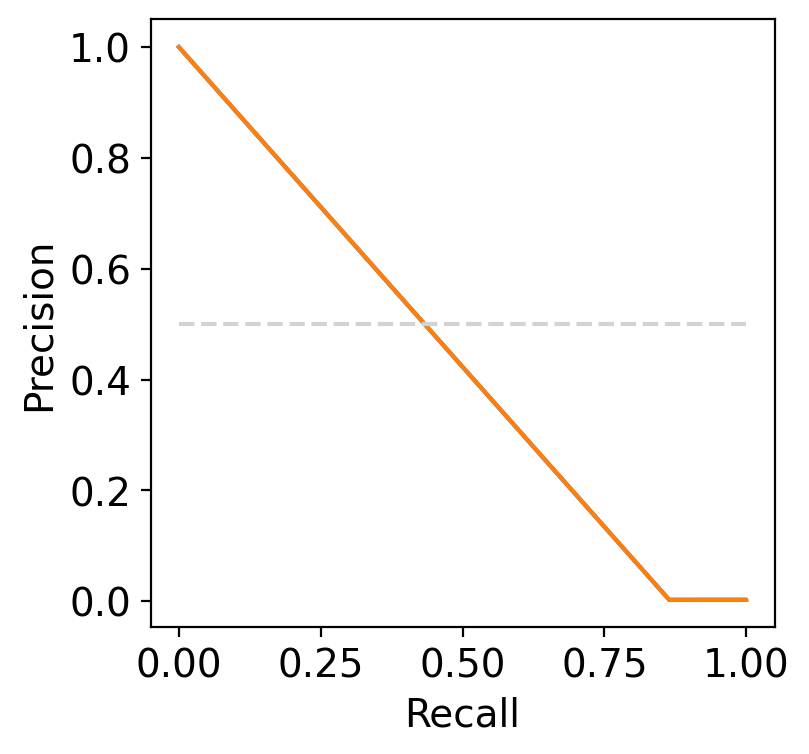

In [262]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [263]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

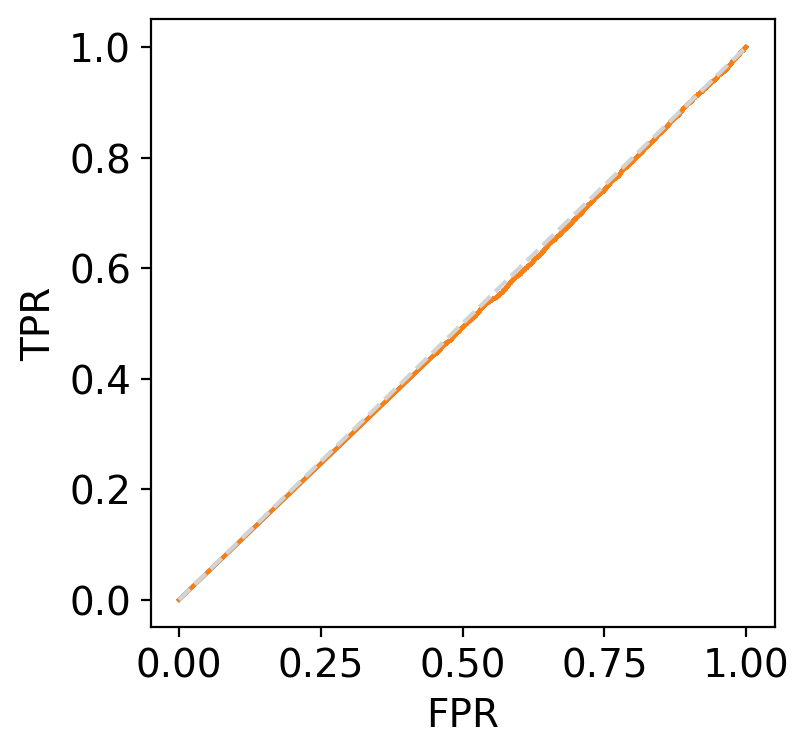

In [264]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

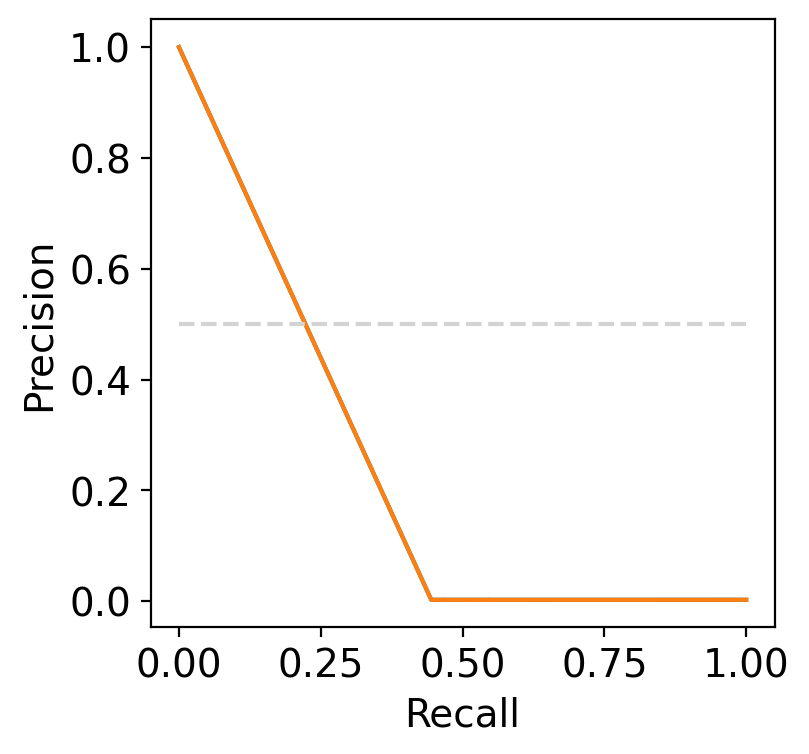

In [265]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

## use less genes with filtering

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


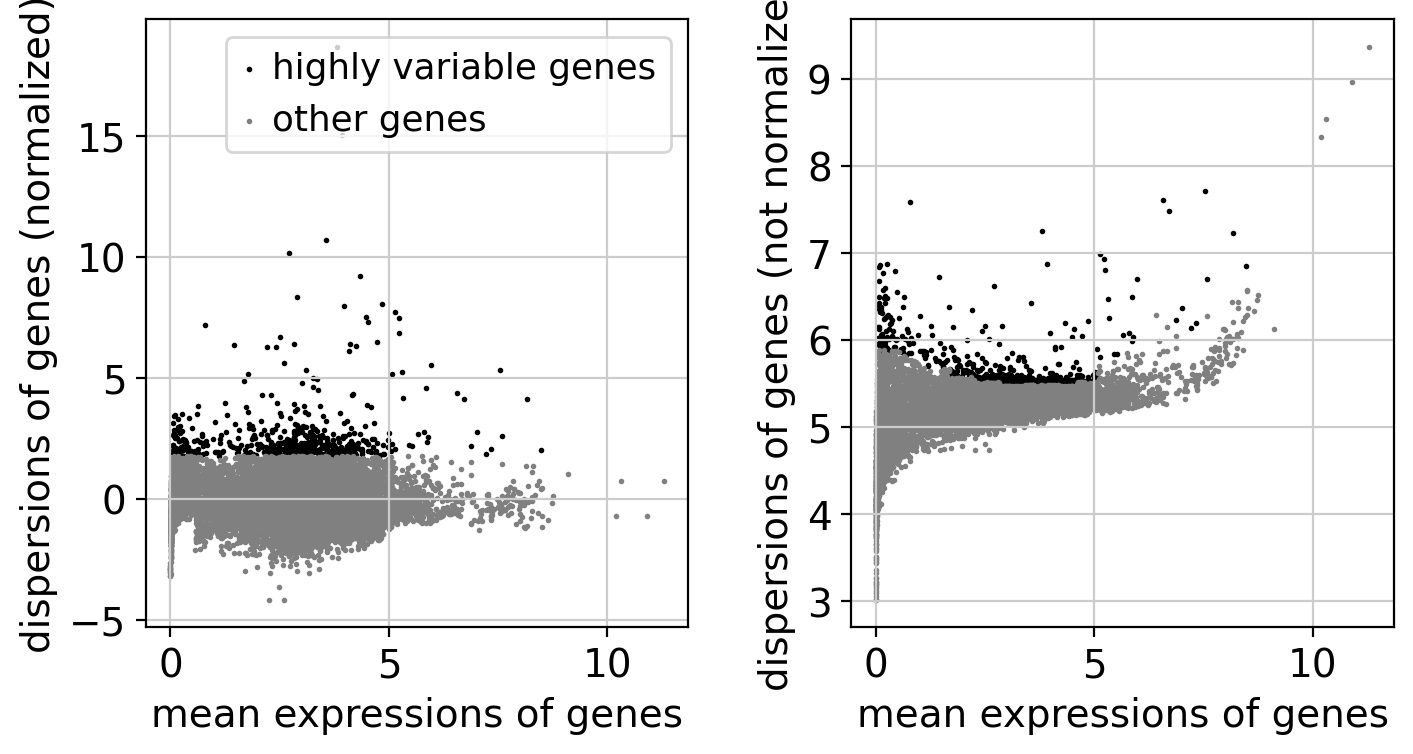

there are 500 hvgs


In [269]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

In [270]:
# > lymph node
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
avis2 = avis.copy()
# add necessary attributes from metadata
avis2.obs['sample_id'] = 'sample'
avis2.obsm['spatial'] = avis2.obs[['imagerow','imagecol']].values

In [271]:
# retrieve the ENSG to GENE SYMBOL conversion
symbol2id = avis2.var.loc[avis2.var.index.intersection(genes), 'gene_id'].to_dict()
id2symbol = {v:k for k,v in symbol2id.items()}

In [272]:
# read in the PPI via HURI
pairs = pd.read_table('data/HI-union.tsv', header=None)
# convert to symbol and remove the irrelevant
pairs[0] = pairs[0].map(id2symbol)
pairs[1] = pairs[1].map(id2symbol)
pairs = pairs.dropna()
# check how many genes are relevant
genes = list(set(pairs.values.flatten()))
print(len(genes))
pairs = [sorted(x) for x in pairs.values.tolist()]

69


In [273]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()
avis1 = avis1[avis1.X.sum(1).A1 > 0].copy()
avis2 = avis2[avis2.X.sum(1) > 0].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('../celcomen/data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('../celcomen/data/preproc_lymphnode.h5ad')

In [275]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_lymphnode.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 69], edge_index=[2, 0], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 69], edge_index=[2, 0], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 69], edge_index=[2, 0], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 69], edge_index=[2, 0], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4023, 69], edge_index=[2, 0], y=[1], pos=[4023, 2], batch=[4023], ptr=[2])



In [276]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-2
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 13.08it/s]


In [277]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-4
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model2.to('cpu')
# train the models
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 24.09it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

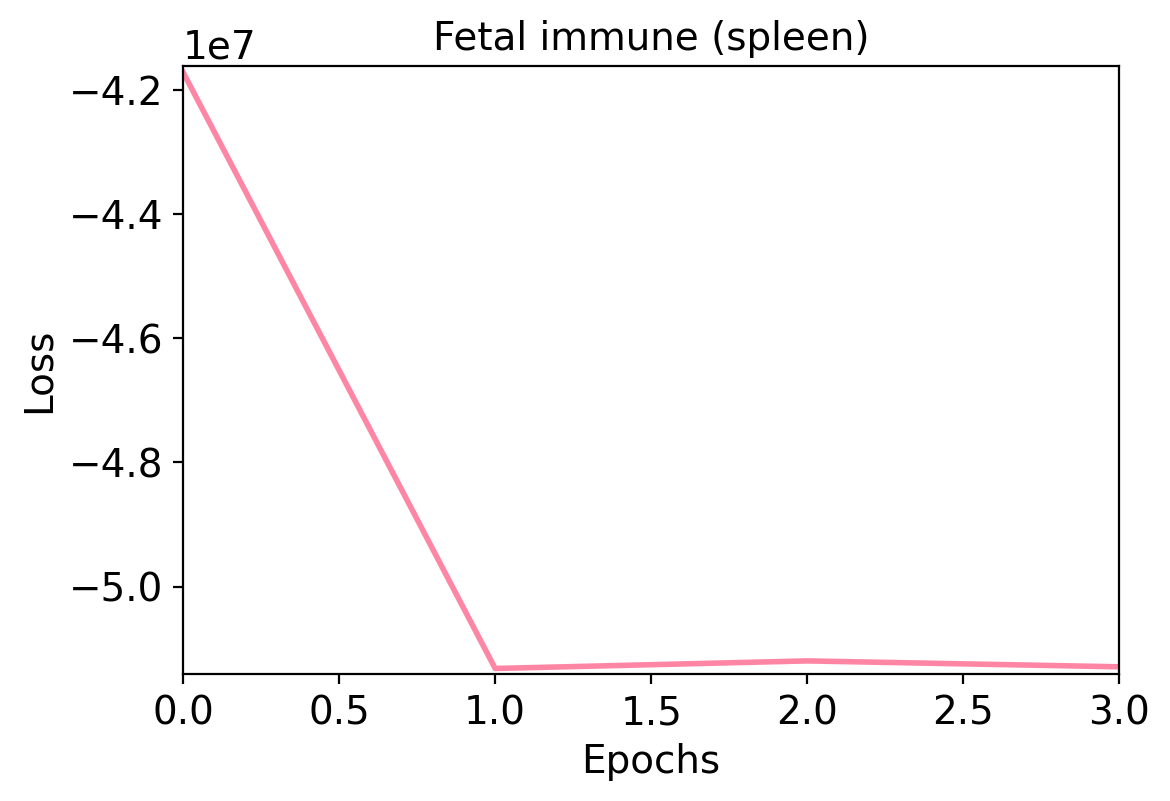

In [278]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

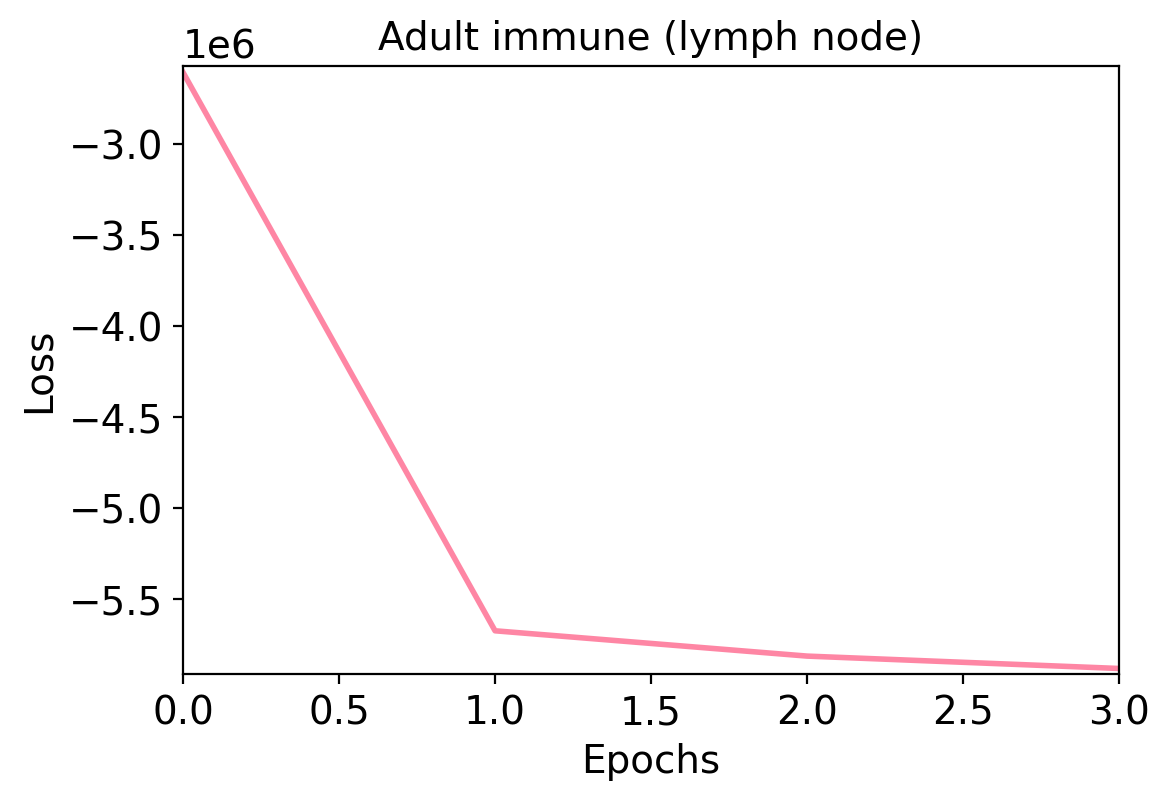

In [279]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

### systematic evaluation

In [280]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

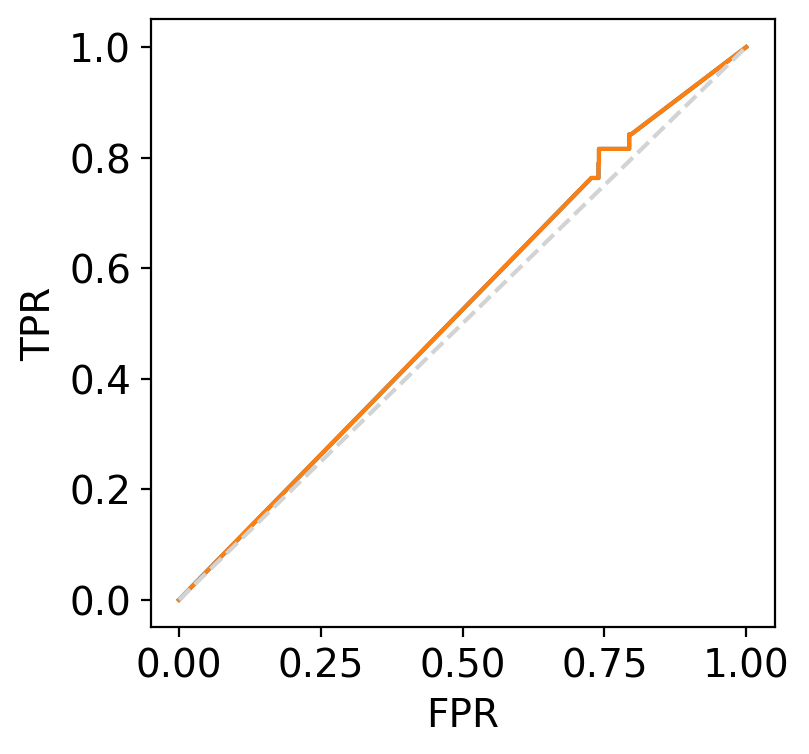

In [282]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

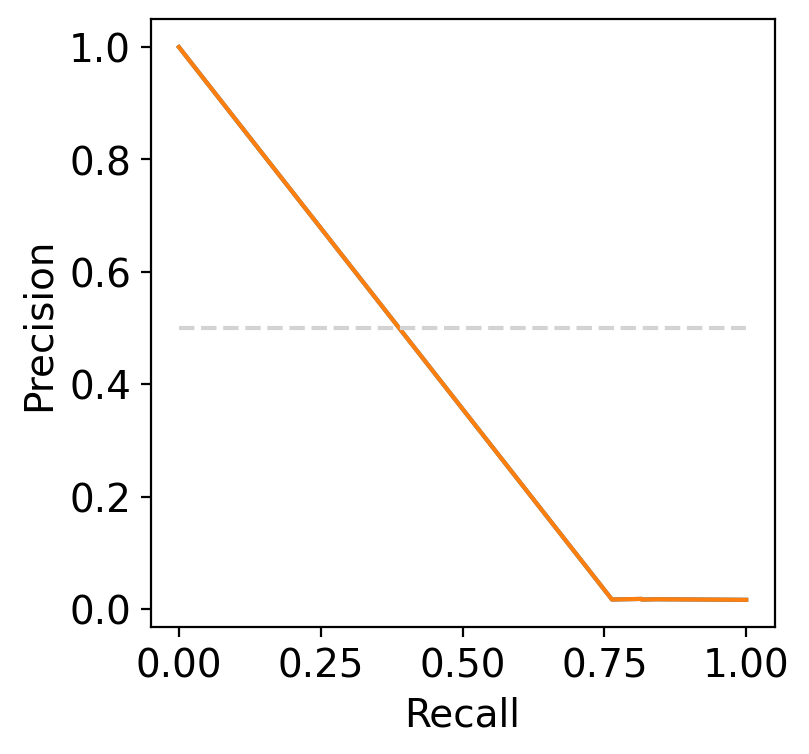

In [283]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [284]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

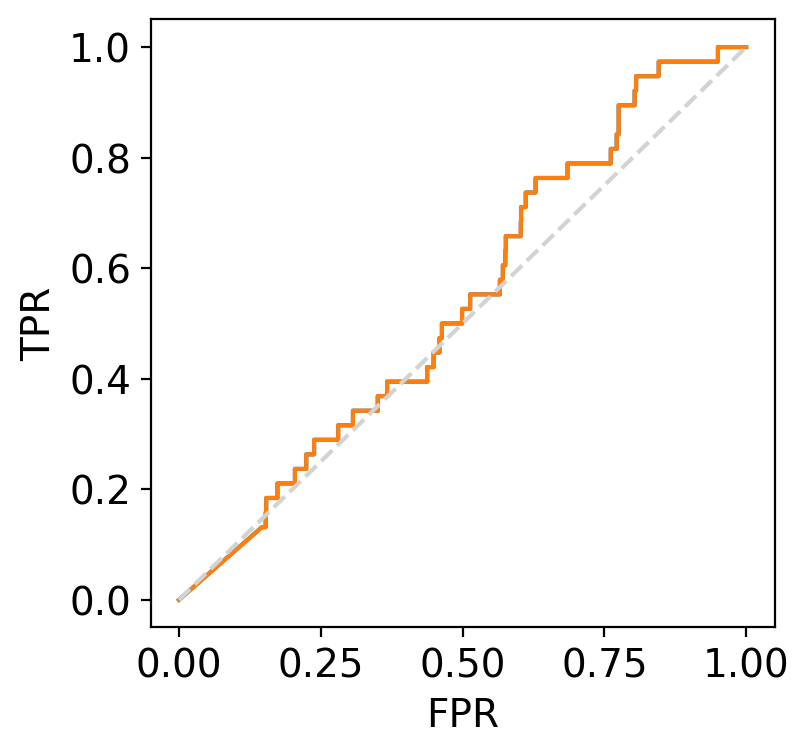

In [285]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

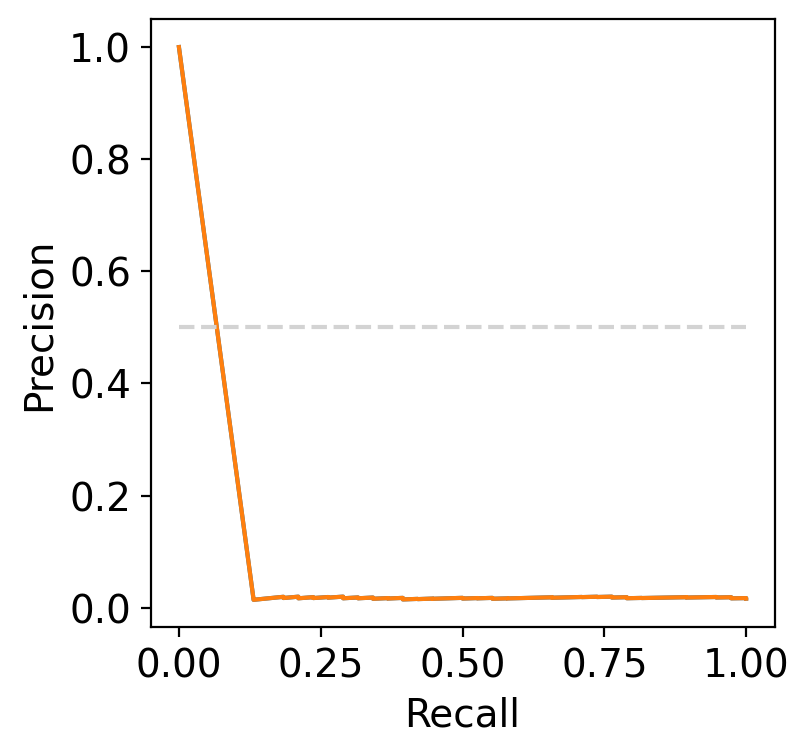

In [286]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

## use less genes without filtering

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


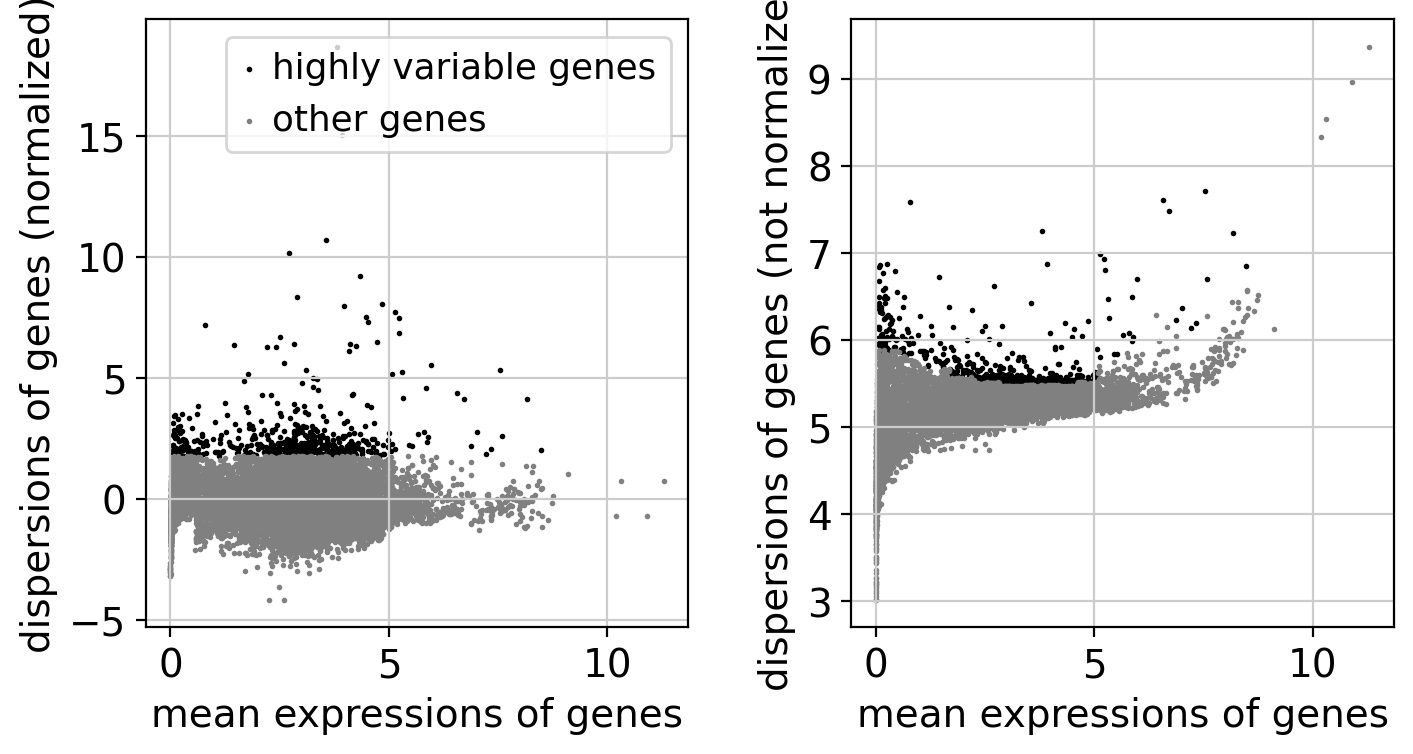

there are 500 hvgs


In [317]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

In [318]:
# > lymph node
# read in the data
avis = sc.read_h5ad('../ccc/data/external/10x_multiorgans/lymphnode.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
avis2 = avis.copy()
# add necessary attributes from metadata
avis2.obs['sample_id'] = 'sample'
avis2.obsm['spatial'] = avis2.obs[['imagerow','imagecol']].values

In [319]:
# retrieve the ENSG to GENE SYMBOL conversion
symbol2id = avis2.var.loc[avis2.var.index.intersection(genes), 'gene_id'].to_dict()
id2symbol = {v:k for k,v in symbol2id.items()}

In [320]:
# read in the PPI via HURI
pairs = pd.read_table('data/HI-union.tsv', header=None)
# convert to symbol and remove the irrelevant
pairs[0] = pairs[0].map(id2symbol)
pairs[1] = pairs[1].map(id2symbol)
pairs = pairs.dropna()
# check how many genes are relevant
print(len(set(pairs.values.flatten())))
pairs = [sorted(x) for x in pairs.values.tolist()]

69


In [321]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()
avis1 = avis1[avis1.X.sum(1).A1 > 0].copy()
avis2 = avis2[avis2.X.sum(1) > 0].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('../celcomen/data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X)
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('../celcomen/data/preproc_lymphnode.h5ad')

In [322]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_lymphnode.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 500], edge_index=[2, 0], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 500], edge_index=[2, 0], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 500], edge_index=[2, 0], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 500], edge_index=[2, 0], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[4035, 500], edge_index=[2, 0], y=[1], pos=[4035, 2], batch=[4035], ptr=[2])



In [323]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-2
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:01<00:00,  3.21it/s]


In [324]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-4
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model2.to('cpu')
# train the models
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00,  6.64it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

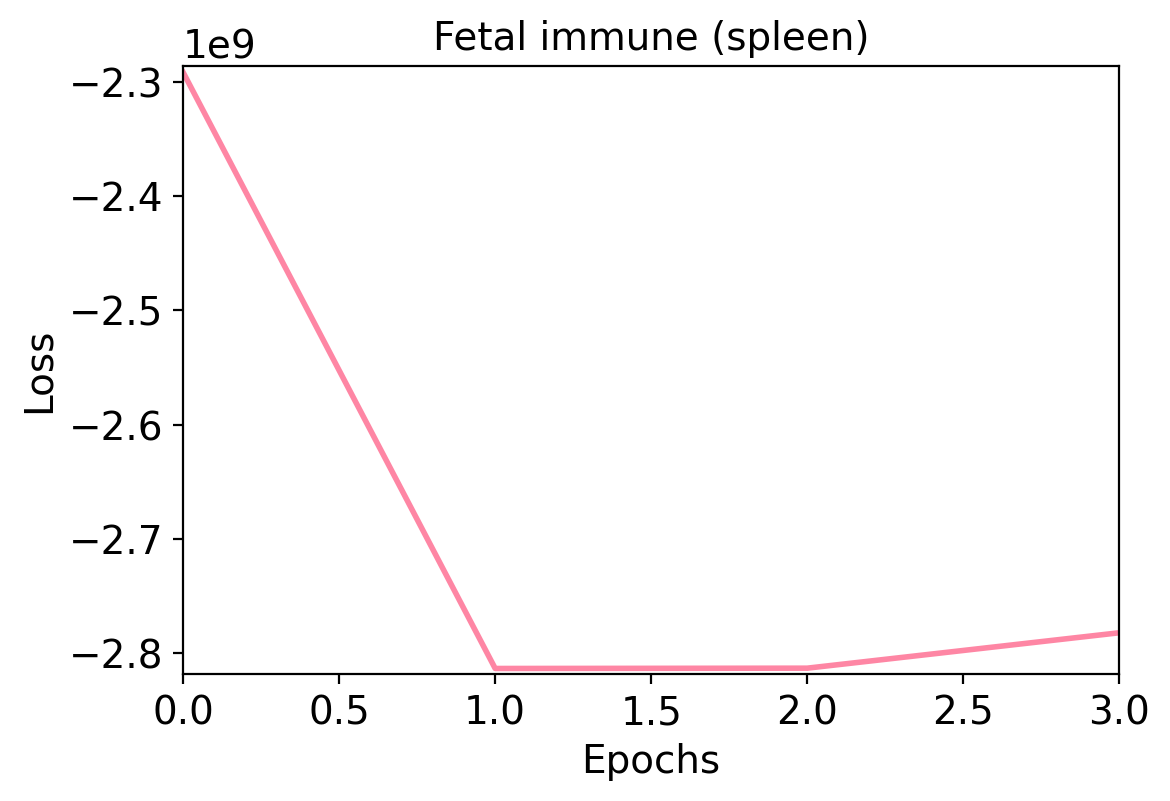

In [325]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult immune (lymph node)')]

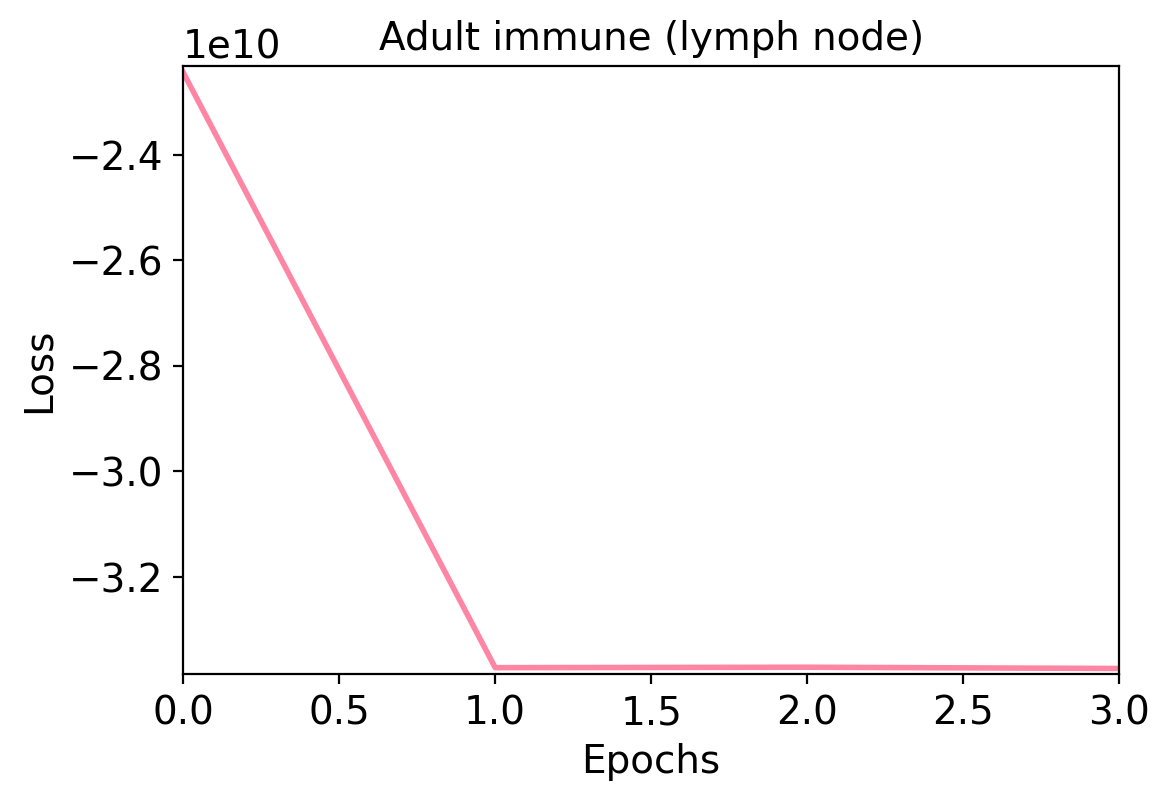

In [326]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult immune (lymph node)')

### systematic evaluation

In [328]:
def retrieve_posneg(df):
    # assemble the data
    tmps = []
    for idx, x in enumerate(df.index):
        tmp = df_inter.loc[x][idx:]
        tmp.index = x + ':' + tmp.index
        tmps.append(tmp)
    tmp = pd.concat(tmps, axis=0)
    print('assembled')
    ys_pred = tmp
    ys_true = 1 * tmp.index.isin(pairs_str)
    return ys_pred, ys_true

In [327]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

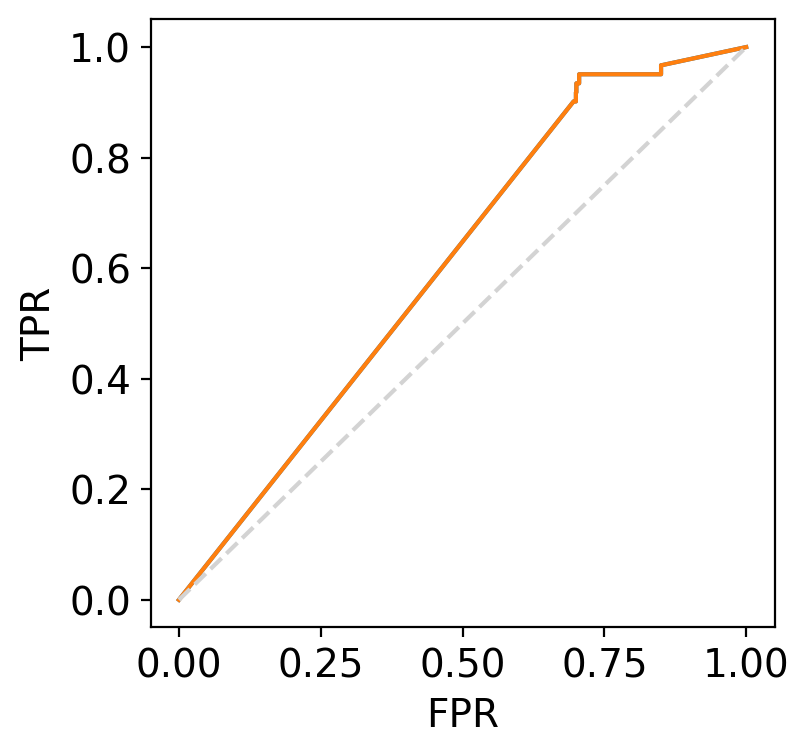

In [329]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

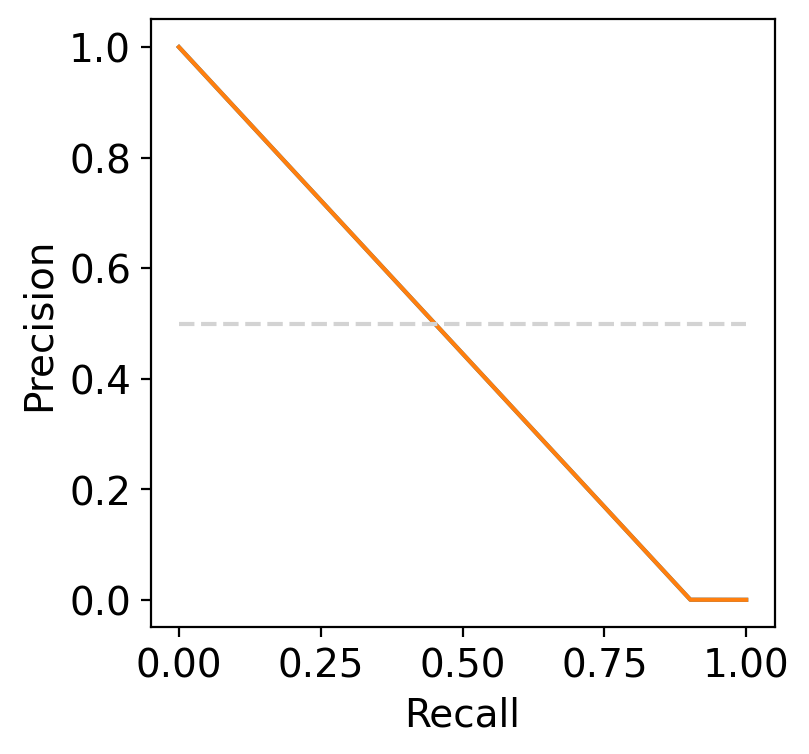

In [330]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [331]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

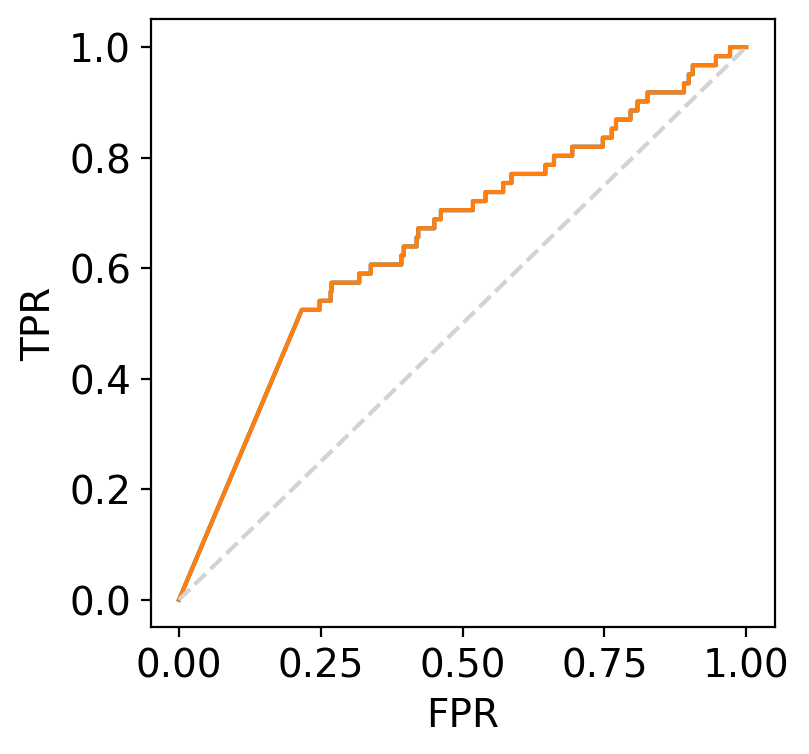

In [332]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

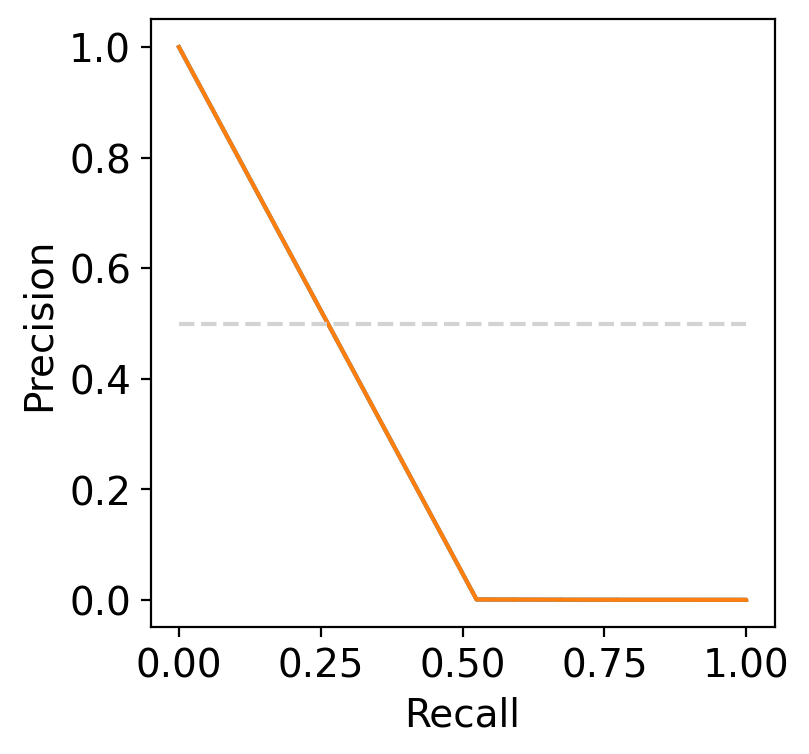

In [333]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

## use less genes without filtering

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


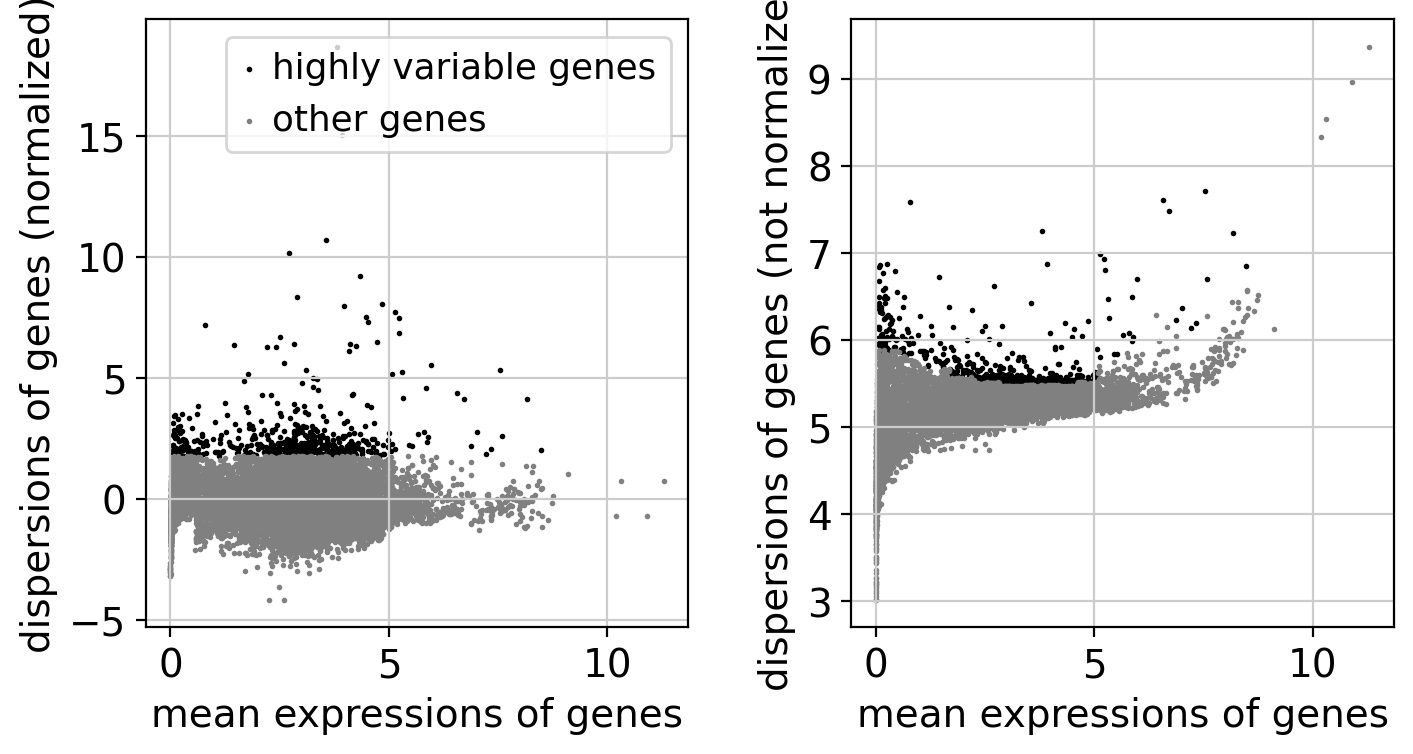

there are 500 hvgs


In [416]:
# > spleen
# read in the data
avis = sc.read_h5ad('../ccc/data/external/fetalimmune/Visium10X_data_SP.h5ad')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# define the sample indexing
sample_col = 'sample_id'
samples = avis.obs[sample_col].unique()
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes1 = avis.var_names[avis.var['highly_variable']].tolist()
avis1 = avis.copy()

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(


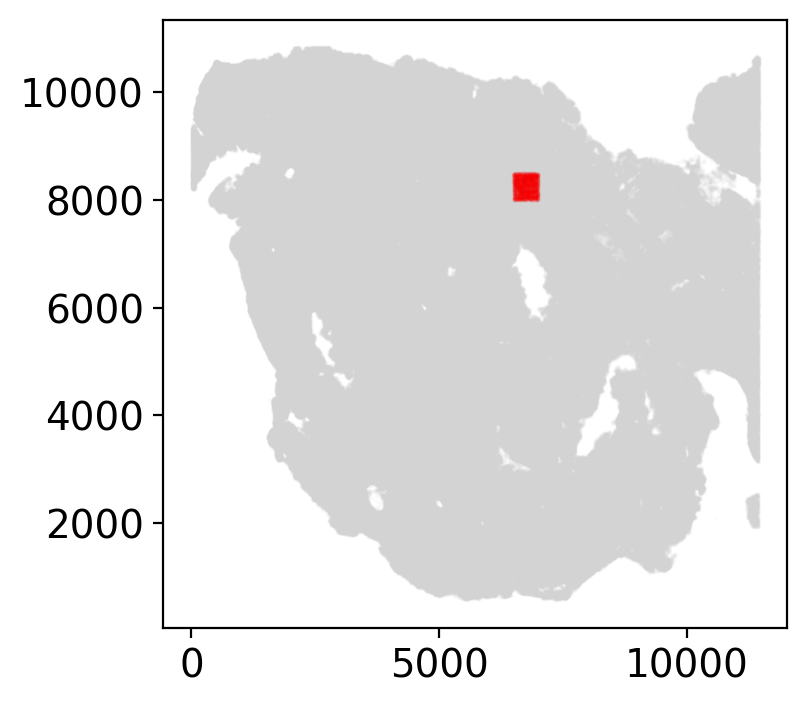

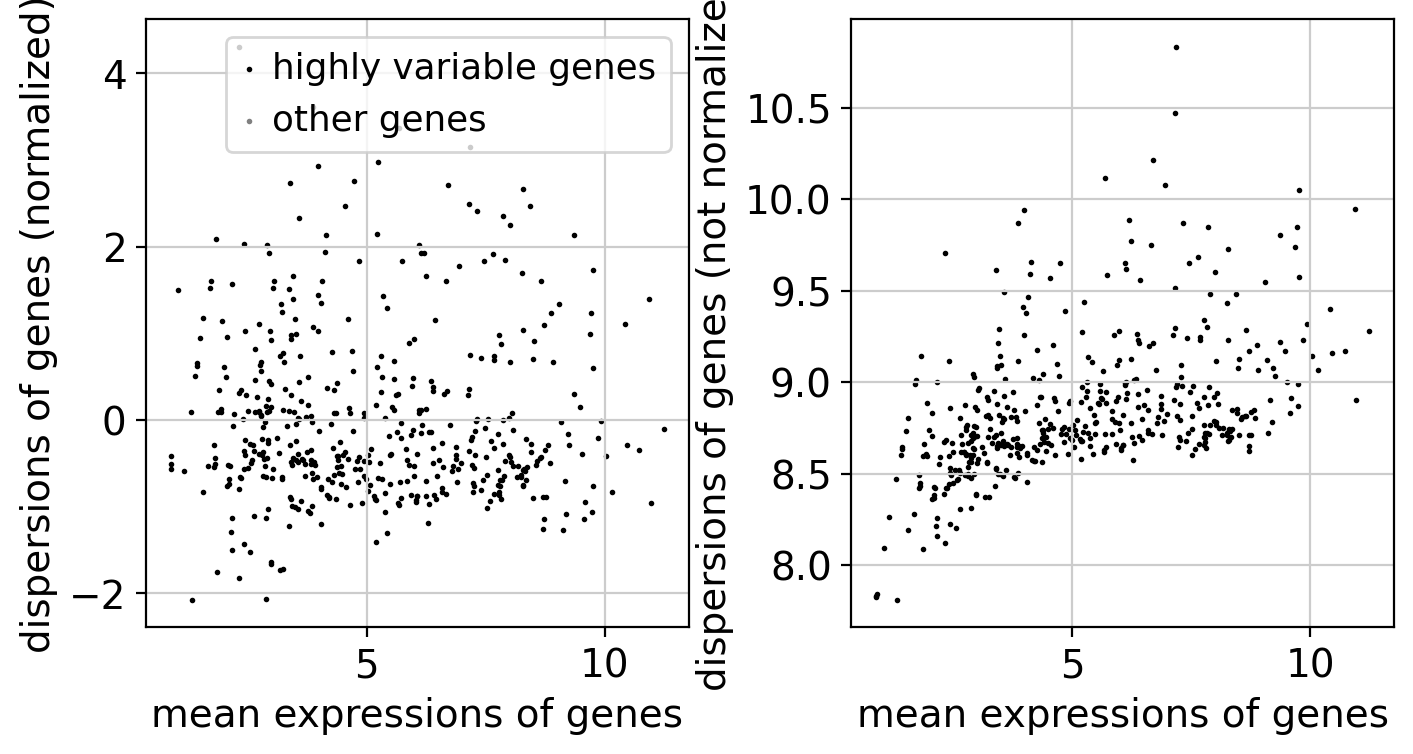

there are 480 hvgs


In [423]:
# > glioblastoma
# read in xenium
avis = sc.read_10x_h5('/home/dchen2/LITERATURE/XENIUM_HUMAN_GBM/cell_feature_matrix.h5')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis, min_counts=100)
# normalize the data
sc.pp.normalize_total(avis, target_sum=1e6)
sc.pp.log1p(avis)
# read in the spatial
df = pd.read_csv('/home/dchen2/LITERATURE/XENIUM_HUMAN_GBM/cells.csv.gz', index_col=0)
df = df.loc[avis.obs.index]
# view the tissue and choose a specific area to focus on
fig, ax = plt.subplots()
ax.grid(False)
ax.scatter(df['x_centroid'], df['y_centroid'], s=0.1, alpha=0.1, color='lightgray')
mask = (df['x_centroid'] < 7000) & (df['x_centroid'] > 6500)
mask = mask & (df['y_centroid'] < 8500) & (df['y_centroid'] > 8000)
ax.scatter(df.loc[mask, 'x_centroid'], df.loc[mask, 'y_centroid'], s=0.1, alpha=0.1, color='r')
# add spatial and subset
avis.obsm['spatial'] = df.loc[avis.obs.index, ['x_centroid','y_centroid']].values
avis = avis[mask].copy()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
# create a gene subset for testing
genes2 = avis.var_names[avis.var['highly_variable']].tolist()
avis2 = avis.copy()
avis2.obs['sample_id'] = 'sample'

In [424]:
from scipy.sparse import csr_matrix
# create a gene subset for testing
genes = pd.Index(genes1).union(pd.Index(genes2))
genes = genes.intersection(avis1.var.index).intersection(avis2.var.index)
print(genes)
avis1 = avis1[:, genes].copy()
avis2 = avis2[:, genes].copy()

# convert the gene expression data to numpy and sphere normalize
# > spleen
x = torch.from_numpy(avis1.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis1.X = csr_matrix(torch.div(x, norm_factor))
avis1.write_h5ad('../celcomen/data/preproc_spleen.h5ad')
# > lymph node
x = torch.from_numpy(avis2.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis2.X = csr_matrix(torch.div(x, norm_factor))
avis2.write_h5ad('../celcomen/data/preproc_gbm.h5ad')

Index(['A2M', 'ACKR1', 'ACTA2', 'ACTB', 'ACTG2', 'ADAM28', 'ADAMTS1', 'AHSP',
       'AIF1', 'AKT1',
       ...
       'TUBB', 'TXLNA', 'UBE2C', 'VCAN', 'VEGFA', 'VSIG4', 'VSIR', 'VWF',
       'XBP1', 'ZNF683'],
      dtype='object', length=434)


In [425]:
# load in spleen and lymph node
n_neighbors = 6
loader1 = get_dataset_loaders('data/preproc_spleen.h5ad', 'sample_id', n_neighbors, 'cpu', True, )
loader2 = get_dataset_loaders('data/preproc_gbm.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[2152, 434], edge_index=[2, 0], y=[1], pos=[2152, 2], batch=[2152], ptr=[2])

Step 2
=====
Number of graphs in the current batch: 1
DataBatch(x=[3103, 434], edge_index=[2, 0], y=[1], pos=[3103, 2], batch=[3103], ptr=[2])

Step 3
=====
Number of graphs in the current batch: 1
DataBatch(x=[2432, 434], edge_index=[2, 0], y=[1], pos=[2432, 2], batch=[2432], ptr=[2])

Step 4
=====
Number of graphs in the current batch: 1
DataBatch(x=[3100, 434], edge_index=[2, 0], y=[1], pos=[3100, 2], batch=[3100], ptr=[2])

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[1781, 434], edge_index=[2, 7724], y=[1], pos=[1781, 2], batch=[1781], ptr=[2])



In [430]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-2
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model1 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model1.set_g2g(torch.from_numpy(input_g2g))
model1.set_g2g_intra(torch.from_numpy(input_g2g))
model1.to('cpu')
# train the models
losses1 = train(epochs, learning_rate, model1, loader1, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:01<00:00,  3.58it/s]


In [431]:
# define hyperparameters
n_genes = len(genes)
learning_rate = 1e-4
zmft_scalar = 1e-1
seed = 0
epochs = 4

# instantiate models on cpu
model2 = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model2.set_g2g(torch.from_numpy(input_g2g))
model2.set_g2g_intra(torch.from_numpy(input_g2g))
model2.to('cpu')
# train the models
losses2 = train(epochs, learning_rate, model2, loader2, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 21.30it/s]


[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Fetal immune (spleen)')]

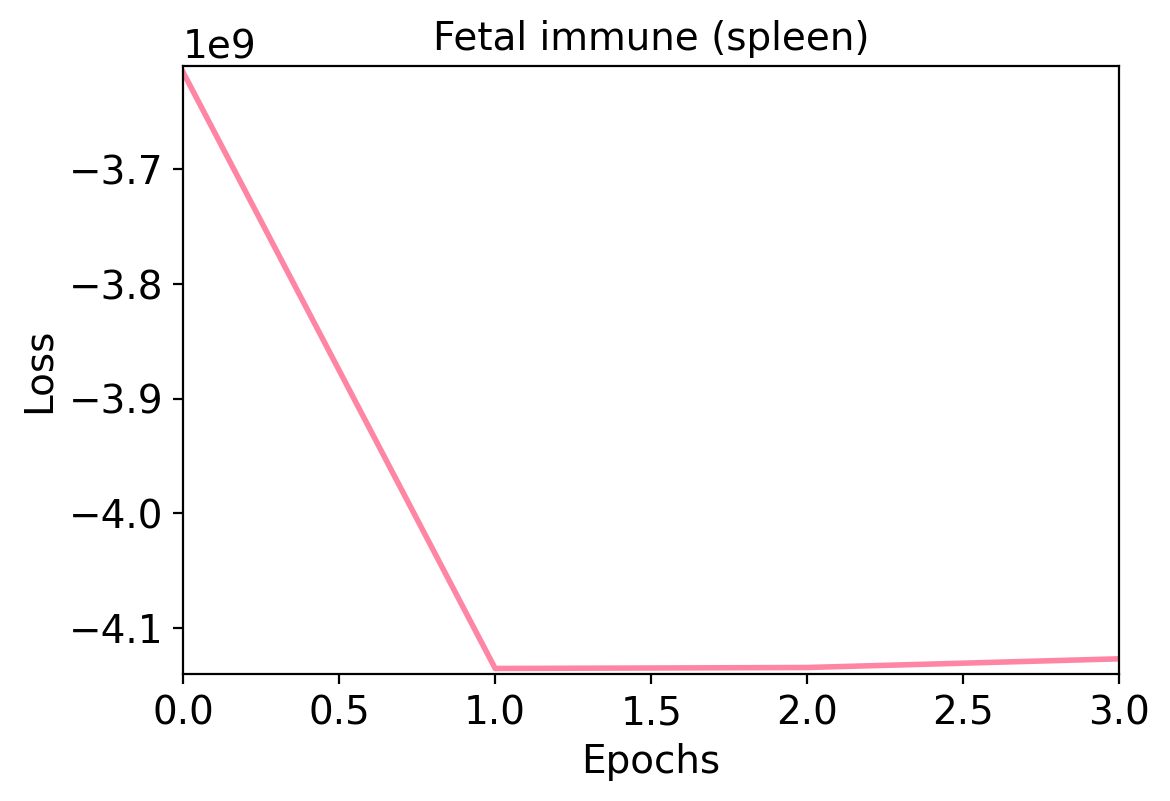

In [432]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses1, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses1), 0), max(losses1)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Fetal immune (spleen)')

[Text(0.5, 0, 'Epochs'),
 Text(0, 0.5, 'Loss'),
 Text(0.5, 1.0, 'Adult brain (GBM)')]

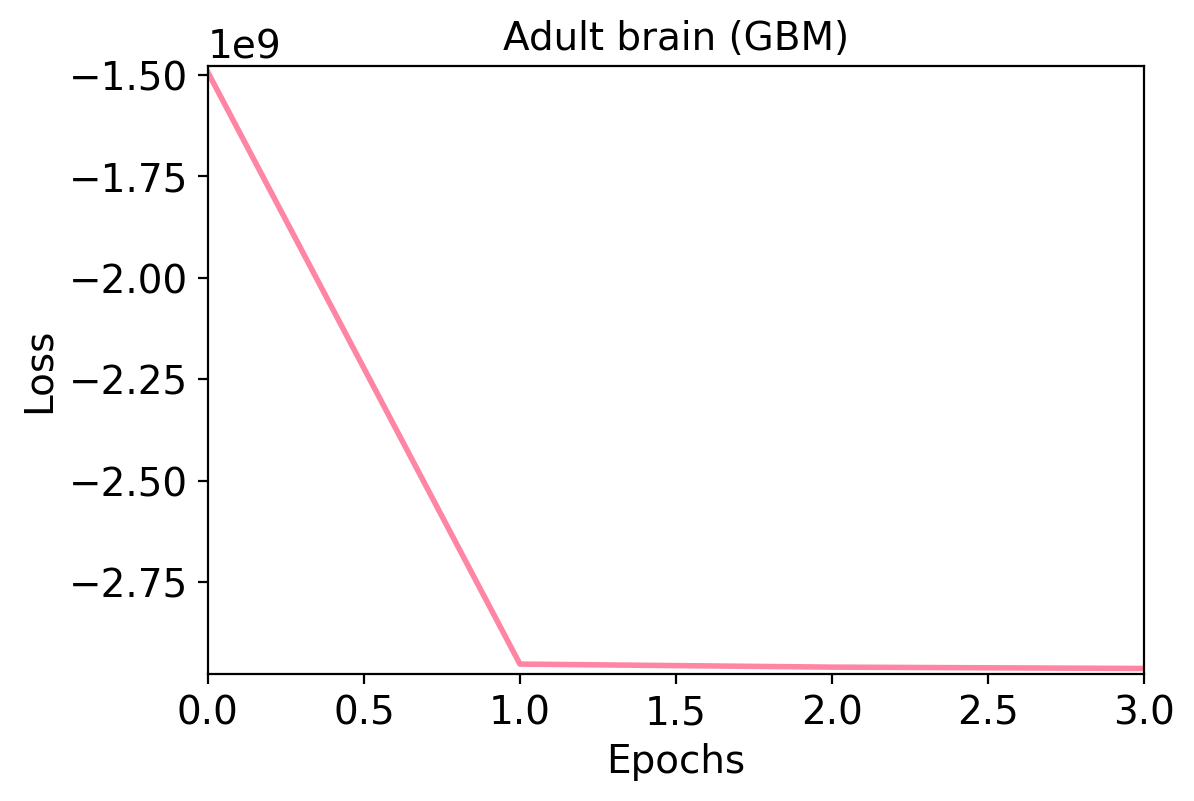

In [433]:
# create the plot for lymph node
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses2, lw=2, color='#fe86a4')
ax.set_xlim(0, 3)
vmin, vmax = min(min(losses2), 0), max(losses2)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='Adult brain (GBM)')

### systematic evaluation

In [434]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model1.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model1.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

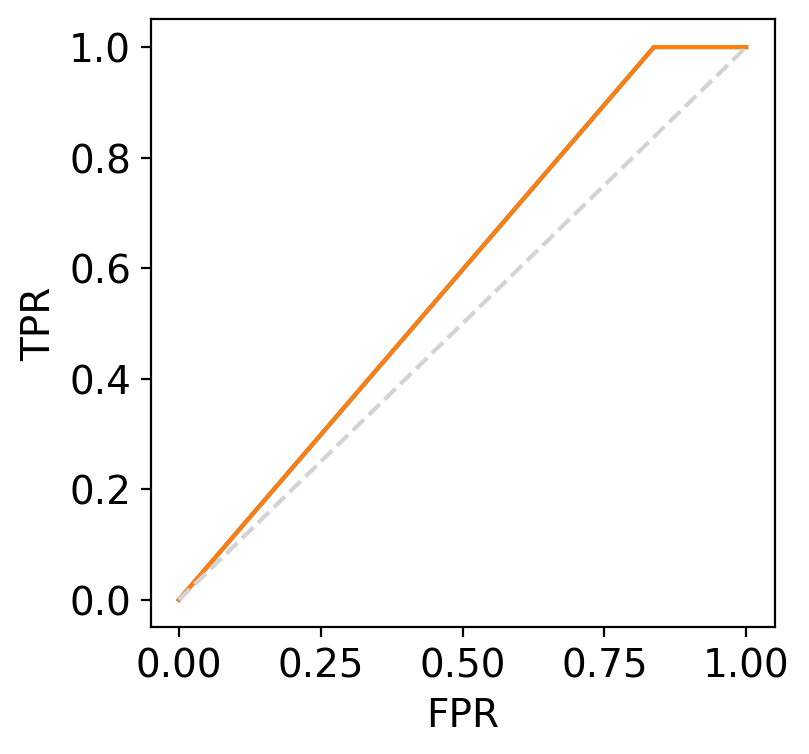

In [435]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

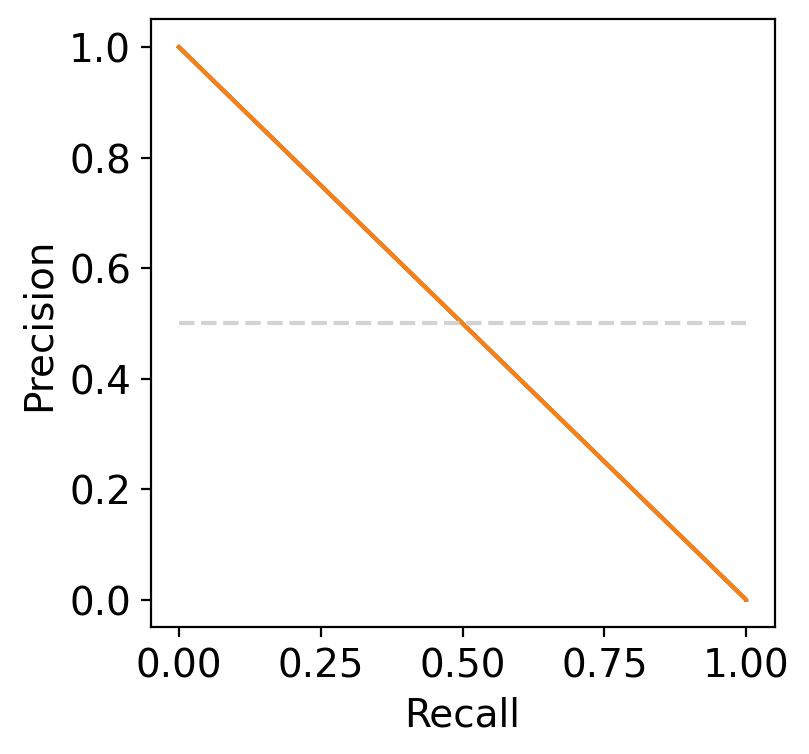

In [436]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

In [437]:
# retrieve the relevant intercellular and intracellular weights for PPIs
df_inter = pd.DataFrame(model2.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model2.lin.weight.detach().numpy(), index=genes, columns=genes)

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

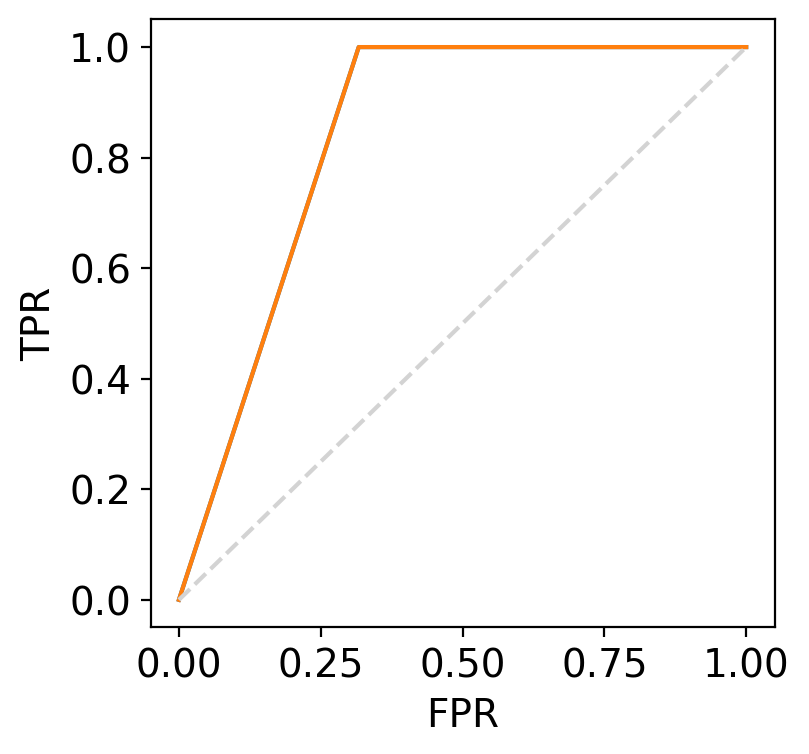

In [438]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

assembled
assembled


[Text(0.5, 0, 'Recall'), Text(0, 0.5, 'Precision')]

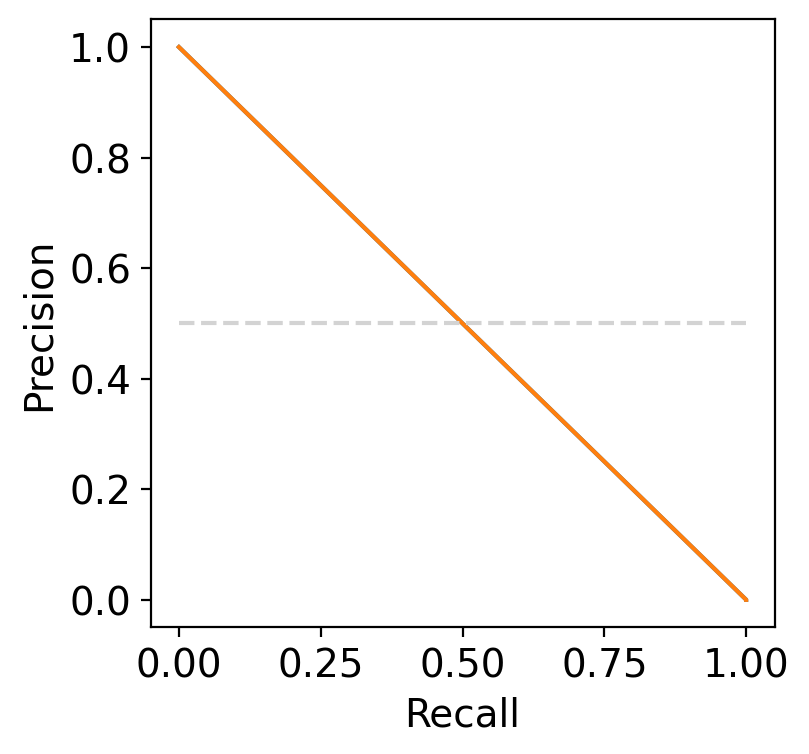

In [439]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
prec, recall, _ = precision_recall_curve(ys_true, ys_pred)
ax.plot(recall, prec)
ax.plot([0, 1], [0.5]*2, color='lightgray', linestyle='--')
ax.set(xlabel='Recall', ylabel='Precision')

## only look at GBM

/home/dchen2/anaconda3/envs/base_py39/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(


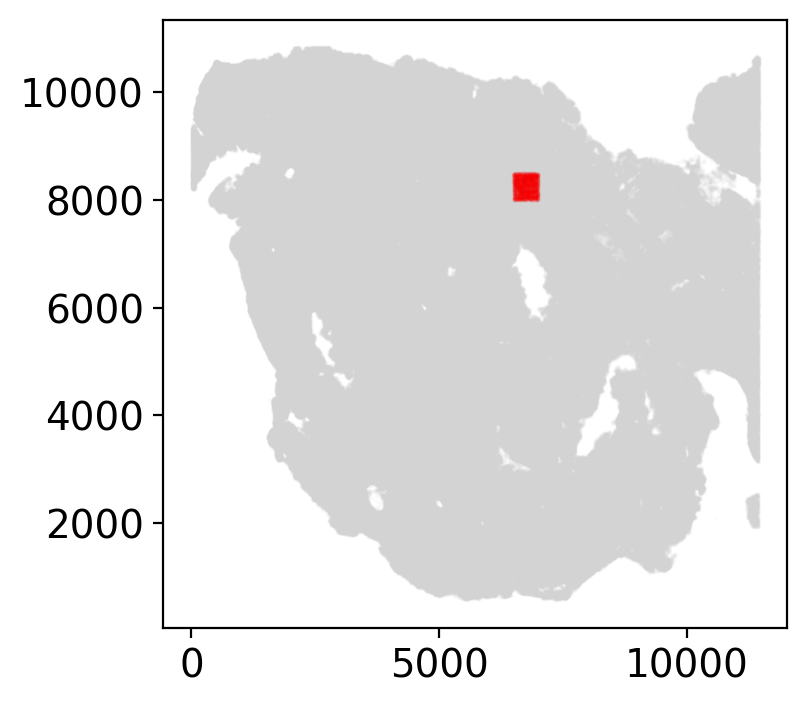

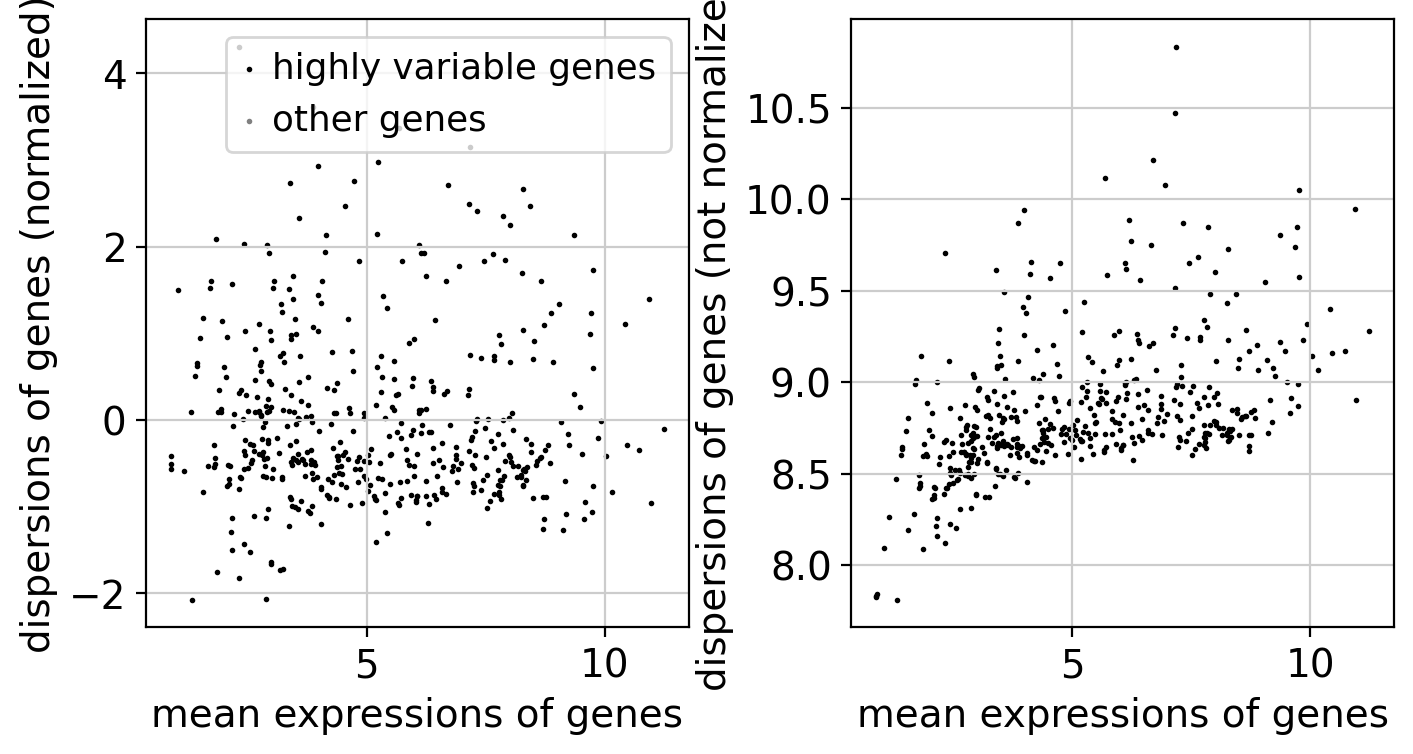

there are 480 hvgs


In [440]:
# > glioblastoma
# read in xenium
avis = sc.read_10x_h5('/home/dchen2/LITERATURE/XENIUM_HUMAN_GBM/cell_feature_matrix.h5')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis, min_counts=100)
# normalize the data
sc.pp.normalize_total(avis, target_sum=1e6)
sc.pp.log1p(avis)
# read in the spatial
df = pd.read_csv('/home/dchen2/LITERATURE/XENIUM_HUMAN_GBM/cells.csv.gz', index_col=0)
df = df.loc[avis.obs.index]
# view the tissue and choose a specific area to focus on
fig, ax = plt.subplots()
ax.grid(False)
ax.scatter(df['x_centroid'], df['y_centroid'], s=0.1, alpha=0.1, color='lightgray')
mask = (df['x_centroid'] < 7000) & (df['x_centroid'] > 6500)
mask = mask & (df['y_centroid'] < 8500) & (df['y_centroid'] > 8000)
ax.scatter(df.loc[mask, 'x_centroid'], df.loc[mask, 'y_centroid'], s=0.1, alpha=0.1, color='r')
# add spatial and subset
avis.obsm['spatial'] = df.loc[avis.obs.index, ['x_centroid','y_centroid']].values
avis = avis[mask].copy()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, n_top_genes=500)
sc.pl.highly_variable_genes(avis)
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')
avis.obs['sample_id'] = 'sample'

In [441]:
from scipy.sparse import csr_matrix
# convert the gene expression data to numpy and sphere normalize
x = torch.from_numpy(avis.X.toarray())
norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
assert (norm_factor > 0).all()
avis.X = csr_matrix(torch.div(x, norm_factor))
avis.write_h5ad('../celcomen/data/preproc_gbm.h5ad')

In [481]:
# load in spleen and lymph node
n_neighbors = 6
loader = get_dataset_loaders('data/preproc_gbm.h5ad', 'sample_id', n_neighbors, 'cpu', True, )

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[1781, 480], edge_index=[2, 7724], y=[1], pos=[1781, 2], batch=[1781], ptr=[2])



In [482]:
# define hyperparameters
n_genes = avis.shape[1]
learning_rate = 1e-5
zmft_scalar = 1e-1
seed = 0
epochs = 10

# instantiate models on cpu
model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
# initialize the g2g matrix
input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model.set_g2g(torch.from_numpy(input_g2g))
model.set_g2g_intra(torch.from_numpy(input_g2g))
model.to('cpu')
# train the models
losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=seed, device='cpu')

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 21.25it/s]


[Text(0.5, 0, 'Epochs'), Text(0, 0.5, 'Loss'), Text(0.5, 1.0, 'GBM')]

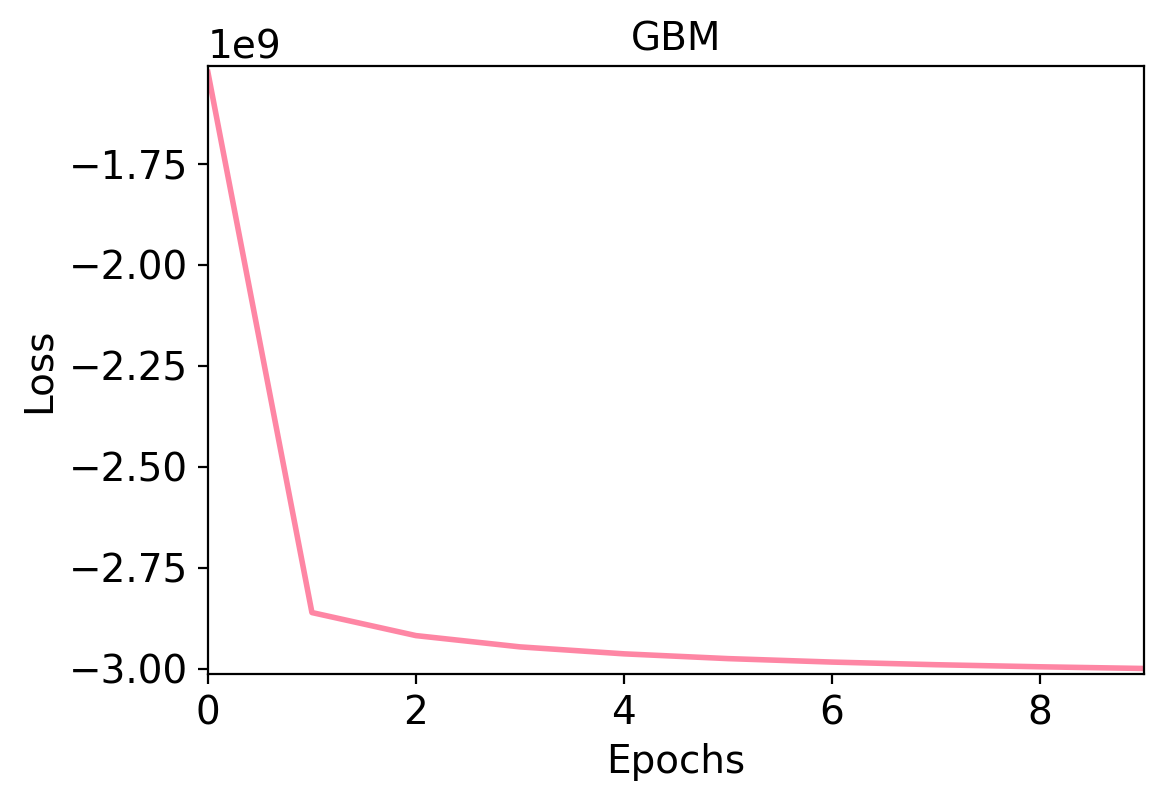

In [483]:
# create the plot for spleen
fig, ax = plt.subplots(figsize=[6, 4])
ax.grid(False)
ax.plot(losses, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs-1)
vmin, vmax = min(min(losses), 0), max(losses)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin-vstep, vmax+vstep)
ax.set(xlabel='Epochs', ylabel='Loss', title='GBM')

### systematic evaluation

In [484]:
# retrieve the relevant intercellular and intracellular weights for PPIs
genes = avis.var.index
df_inter = pd.DataFrame(model.conv1.lin.weight.detach().numpy(), index=genes, columns=genes)
df_intra = pd.DataFrame(model.lin.weight.detach().numpy(), index=genes, columns=genes)

In [485]:
def retrieve_posneg(df):
    # assemble the data
    tmps = []
    for idx, x in enumerate(df.index):
        tmp = df_inter.loc[x][idx:]
        tmp.index = x + ':' + tmp.index
        tmps.append(tmp)
    tmp = pd.concat(tmps, axis=0)
    print('assembled')
    ys_pred = tmp
    ys_true = 1 * tmp.index.isin(pairs_str)
    return ys_pred, ys_true

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

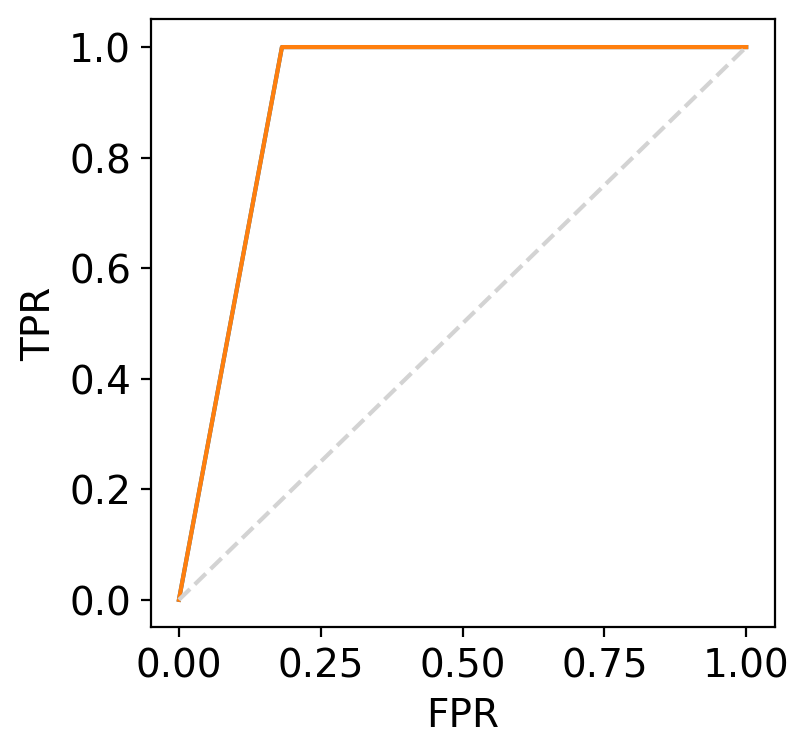

In [486]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

In [487]:
def retrieve_posneg(df):
    # assemble the data
    tmps = []
    for idx, x in enumerate(df.index):
        tmp = df_inter.loc[x][idx+1:]
        tmp.index = x + ':' + tmp.index
        tmps.append(tmp)
    tmp = pd.concat(tmps, axis=0)
    print('assembled')
    ys_pred = tmp
    ys_true = 1 * tmp.index.isin(pairs_str)
    return ys_pred, ys_true

assembled
assembled


[Text(0.5, 0, 'FPR'), Text(0, 0.5, 'TPR')]

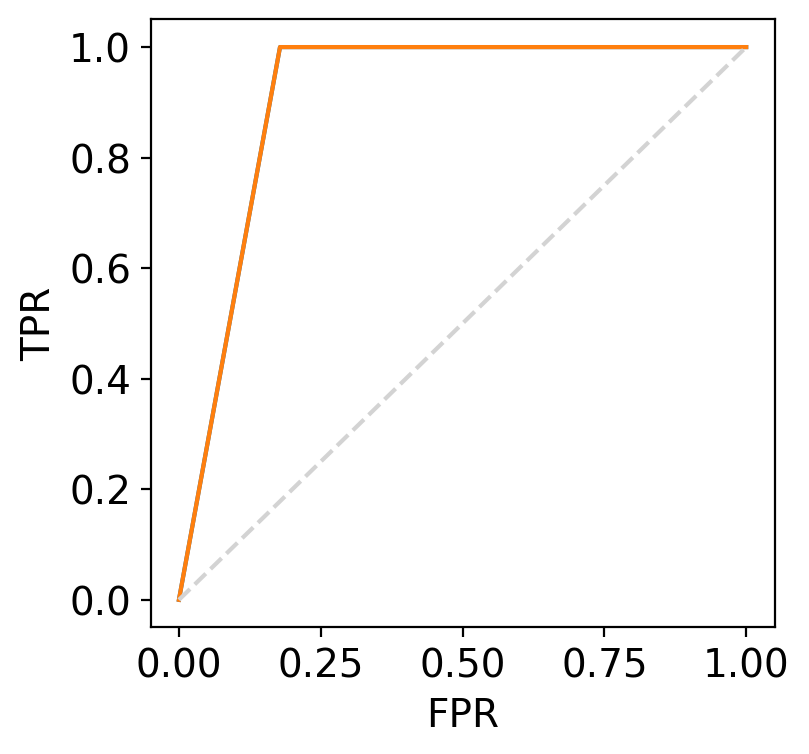

In [488]:
# check for interactions
fig, ax = plt.subplots(figsize=[4, 4]); ax.grid(False)
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
# intra-cellular
ys_pred, ys_true = retrieve_posneg(df_intra)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='lightgray', linestyle='--')
ax.set(xlabel='FPR', ylabel='TPR')

In [489]:
def retrieve_posneg(df):
    # assemble the data
    tmps = []
    for idx, x in enumerate(df.index):
        tmp = df_inter.loc[x][idx:]
        tmp.index = x + ':' + tmp.index
        tmps.append(tmp)
    tmp = pd.concat(tmps, axis=0)
    ys_pred = tmp
    ys_true = 1 * tmp.index.isin(pairs_str)
    return ys_pred, ys_true

In [490]:
# inter-cellular
ys_pred, ys_true = retrieve_posneg(df_inter)
fpr, tpr, _ = roc_curve(ys_true, ys_pred)
auc(fpr, tpr)

0.9091972244600951

In [491]:
# define hyperparameters
n_genes = avis.shape[1]
learning_rate = 1e-5
seed = 0
epochs = 10

In [492]:
# test the zmfts
df_stat = pd.DataFrame(columns=['zmft_scalar','seed','auc_inter','auc_intra'])
for zmft_scalar in np.arange(0, 1+.1, .1):
    # instantiate models on cpu
    np.random.seed(seed)
    model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # initialize the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model.set_g2g(torch.from_numpy(input_g2g))
    model.set_g2g_intra(torch.from_numpy(input_g2g))
    model.to('cpu')
    # train the models
    losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=seed, device='cpu')
    # inter-cellular
    ys_pred, ys_true = retrieve_posneg(df_inter)
    fpr, tpr, _ = roc_curve(ys_true, ys_pred)
    auc_inter = auc(fpr, tpr)
    # intra-cellular
    ys_pred, ys_true = retrieve_posneg(df_intra)
    fpr, tpr, _ = roc_curve(ys_true, ys_pred)
    auc_intra = auc(fpr, tpr)
    df_stat.loc[df_stat.shape[0]] = zmft_scalar, seed, auc_inter, auc_intra

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 22.32it/s]


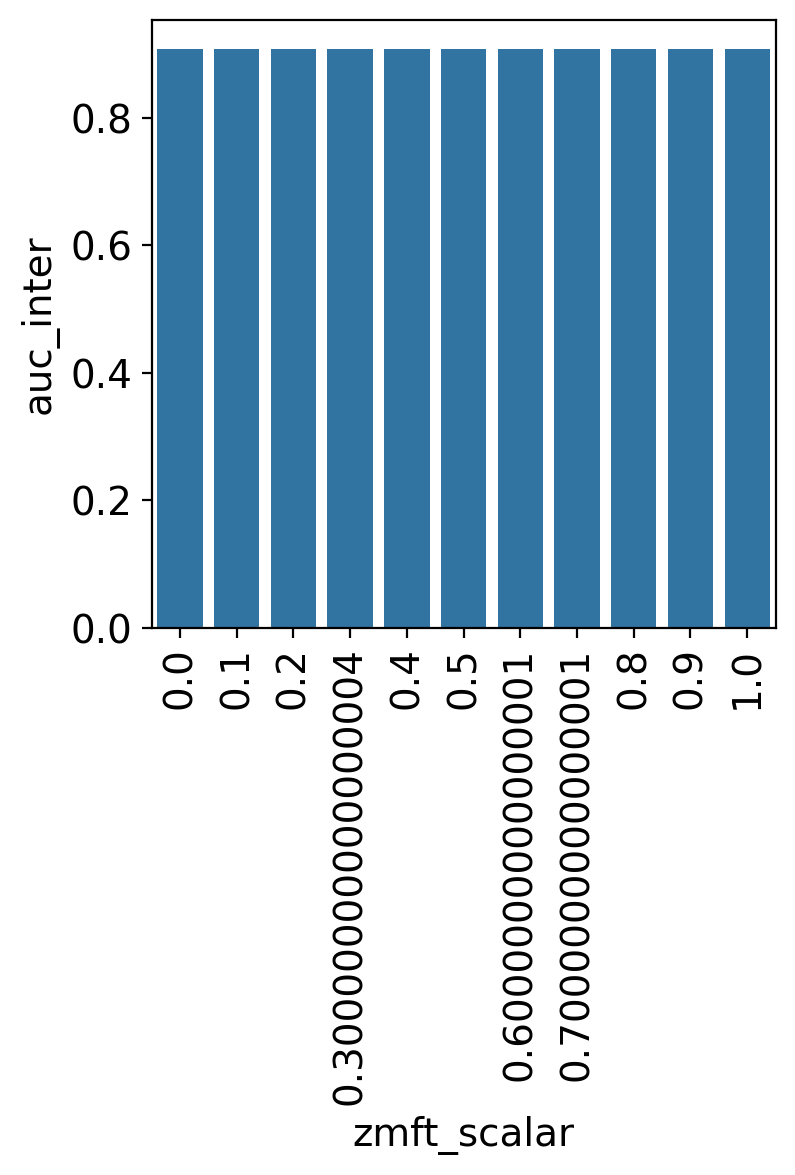

In [496]:
# check auc inter
fig, ax = plt.subplots(); ax.grid(False)
sns.barplot(x='zmft_scalar', y='auc_inter', data=df_stat)
ax.tick_params(axis='x', labelrotation=90)

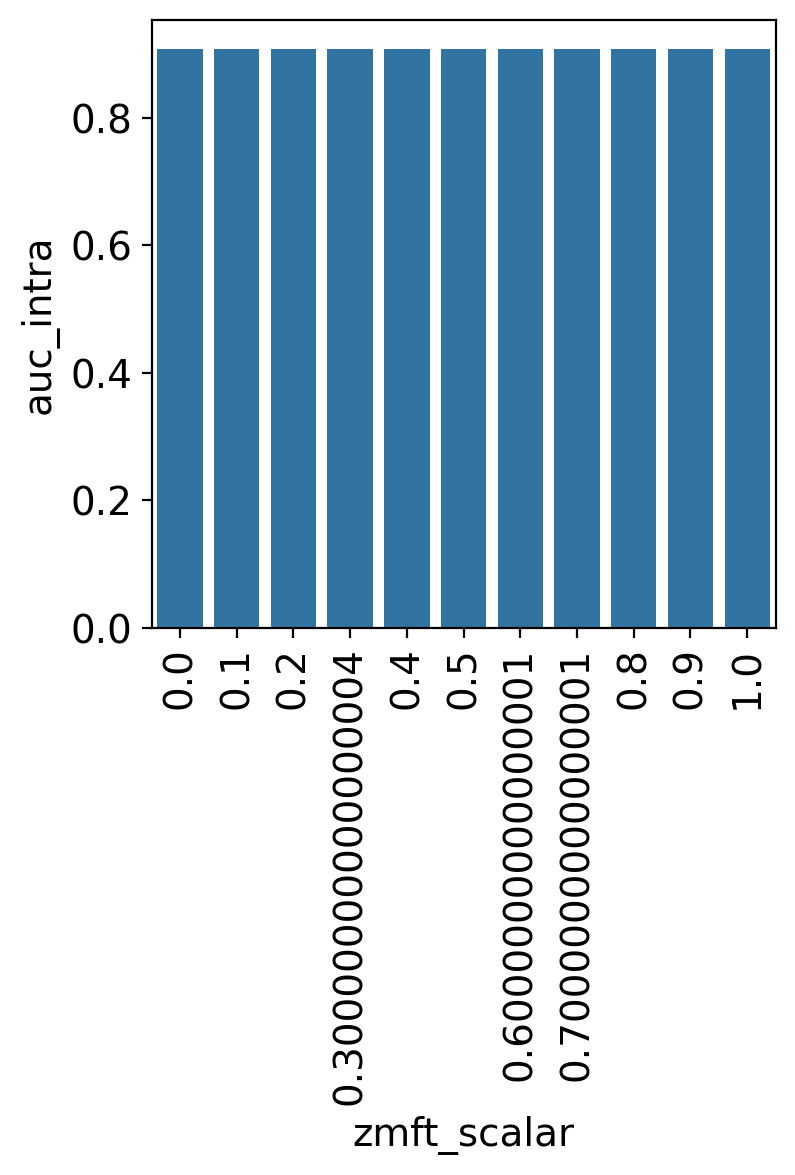

In [497]:
# check auc intra
fig, ax = plt.subplots(); ax.grid(False)
sns.barplot(x='zmft_scalar', y='auc_intra', data=df_stat)
ax.tick_params(axis='x', labelrotation=90)